In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import matplotlib as mpl
import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

In [2]:
# Model

def modBB(f, T, b):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    TT = 30.0 * T        # reason: adjust parameter magnitude
    return f**(b + 3.0) / (np.exp(h * f / (k * TT)) - 1.0)

def modBB_TGrad(f, T, b):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    T *= 30.0            # reason: adjust parameter magnitude
    return 30.0 * h * f**(b + 4.0) * np.exp(h * f / (k * T)) / (k * T**2.0 * (np.exp(h * f / (k * T)) - 1.0)**2.0)

def modBB_bGrad(f, T, b):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    T *= 30.0            # units: adjust parameter magnitude
    return np.log(f) * f**(b + 3.0) / (np.exp(h * f / (k * T)) - 1.0)

def chiSq(I, f, s, T, b):
    return np.sum((I - modBB(f, T, b))**2 / s**2)

def chiSq_TGrad(I, f, s, T, b):
    return np.sum(-2 * (I - modBB(f, T, b)) * modBB_TGrad(f, T, b) / s**2)

def chiSq_bGrad(I, f, s, T, b):
    return np.sum(-2 * (I - modBB(f, T, b)) * modBB_bGrad(f, T, b) / s**2)

def logLike_TGrad(I, f, s, T, b):
    return (I - modBB(f, T, b)) * modBB_TGrad(f, T, b) / s**2

def logLike_bGrad(I, f, s, T, b):
    return (I - modBB(f, T, b)) * modBB_bGrad(f, T, b) / s**2

In [3]:
# Functions

def optGradDesc(I, f, s, T, b, alpha = 7e-7, epsilon = 1e-16):
    theta = np.array([[T / 30.0, b]])
    k = 0
    while True:
        TGrad = chiSq_TGrad(I, f, s, *theta[k, :])
        bGrad = chiSq_bGrad(I, f, s, *theta[k, :])
        theta = np.append(theta, [theta[k, :] - alpha * np.array([TGrad, bGrad])], axis=0)
        k += 1
        if np.abs(theta[k, 0] - theta[k - 1, 0]) / theta[k - 1, 0] \
        < epsilon and np.abs(theta[k, 1] - theta[k - 1, 1]) / theta[k - 1, 1] < epsilon:
            break
        if k >= 100000:
            break
    print('\n')
    print(f'initialization:   T = {T:.2f} K   ß = {b:.3f}')
    print(f'  optimization:   T = {30.0 * theta[-1, 0]:.2f} K   ß = {theta[-1, 1]:.3f}')
    print(f'    iterations:   k = {k}')
    return [theta, k]

def optGradDescLinSearch(I, f, s, T, b, init = 1e-4, epsilon = 1e-16, kappa = 0.5, tau = 0.5):
    theta = np.array([[T / 30.0, b]])
    alpha = np.array([init])
    k = 0
    while True:
        TGrad = chiSq_TGrad(I, f, s, *theta[k, :])
        bGrad = chiSq_bGrad(I, f, s, *theta[k, :])
        j = 0
        while chiSq(I, f, s, *theta[k, :]) \
        - chiSq(I, f, s, *(theta[k, :] - alpha[-1] * np.array([TGrad, bGrad]))) \
        < kappa * alpha[-1] * (TGrad**2 + bGrad**2):
            alpha[-1] *= tau
            j += 1
        theta = np.append(theta, [theta[k, :] - alpha[-1] * np.array([TGrad, bGrad])], axis=0)
        alpha = np.append(alpha, init)
        k += 1
        if np.abs(theta[k, 0] - theta[k - 1, 0]) / theta[k - 1, 0] \
        < epsilon and np.abs(theta[k, 1] - theta[k - 1, 1]) / theta[k - 1, 1] < epsilon:
            break
        if k >= 100000:
            break

    print('\n')
    print(f'initialization:   T = {T:.2f} K   ß = {b:.3f}')
    print(f'  optimization:   T = {30.0 * theta[-1, 0]:.2f} K   ß = {theta[-1, 1]:.3f}')
    print(f'    iterations:   k = {k}')
    return [theta, k, alpha]

def gaussian(par, cov, T, b):
    var = np.array([T, b]) - par
    return np.exp(-0.5 * var.T @ np.linalg.inv(cov) @ var)

def metroMCMC(n, T, b, I, f, s, h = 0.001):
    theta = np.array([[T / 30.0, b]])
    k = 0
    l = 0
    while n > l + 1:
        th = np.random.normal(theta[l, :], [h, h])
        r = np.exp((chiSq(I, f, s, *theta[l, :]) - chiSq(I, f, s, *th)) / 2)
        if r >= 1.0:
            theta = np.append(theta, [th], axis=0)
            l += 1
        else:
            p = np.random.uniform(0.0, 1.0)
            if r >= p:
                theta = np.append(theta, [th], axis=0)
                l += 1
        k += 1
    ac = n / k
    print(f'done:   generated {n} samples after {k:{len(str(n)) + 1}} evaluations with acceptance ratio {100 * ac:.2f}%')
    return [theta, ac]

def rollMean(arr, n):
    ret = np.zeros(len(arr) - n)
    m = 0
    for el in ret:
        ret[m] = np.mean(arr[m:n + m])
        m += 1
    return ret

def rollUnc(arr, n):
    ret = np.zeros(len(arr) - n)
    m = 0
    for el in ret:
        ret[m] = np.std(arr[m:n + m])
        m += 1
    return ret

def autoCorrCoeff(arr, n, m):
    if n + m < len(arr):
        ret = np.zeros(n)
        err = np.zeros(n)
        t = np.array([0])
        for el in ret:
            now = arr[t[-1]:t[-1] + m]
            lag = arr[:m]
            ret[t[-1]] = np.mean((now - np.mean(now)) * (lag - np.mean(lag))) / (np.std(now) * np.std(lag))
            err[t[-1]] = np.sqrt((2 * np.sum(ret**2) - 1) / m)
            t = np.append(t, t[-1] + 1)
        return [ret, err, t[:-1]]

In [4]:
# Setup

np.random.seed(456)   # reason: reproducible pseudo random number generation

TT1, TT2, bb1, bb2 = 12 / 30.0, 18 / 30.0, 1.95, 1.85   # function: true parameters

N = 25                    # function: number of measurements
u = 0.25                  # function: relative uncertainty

ff = 10**np.random.uniform(11, 13, 2 * N)   # function: logarithmically distributed frequencies

ff = np.sort(ff)

II = np.concatenate((modBB(ff[:N], TT1, bb1), modBB(ff[N:], TT2, bb2)))
II += np.random.normal(0.0, u * II)         # function: intensities with gaussian spread around function

uII = u * II                                # function: absolute assumed uncertainty

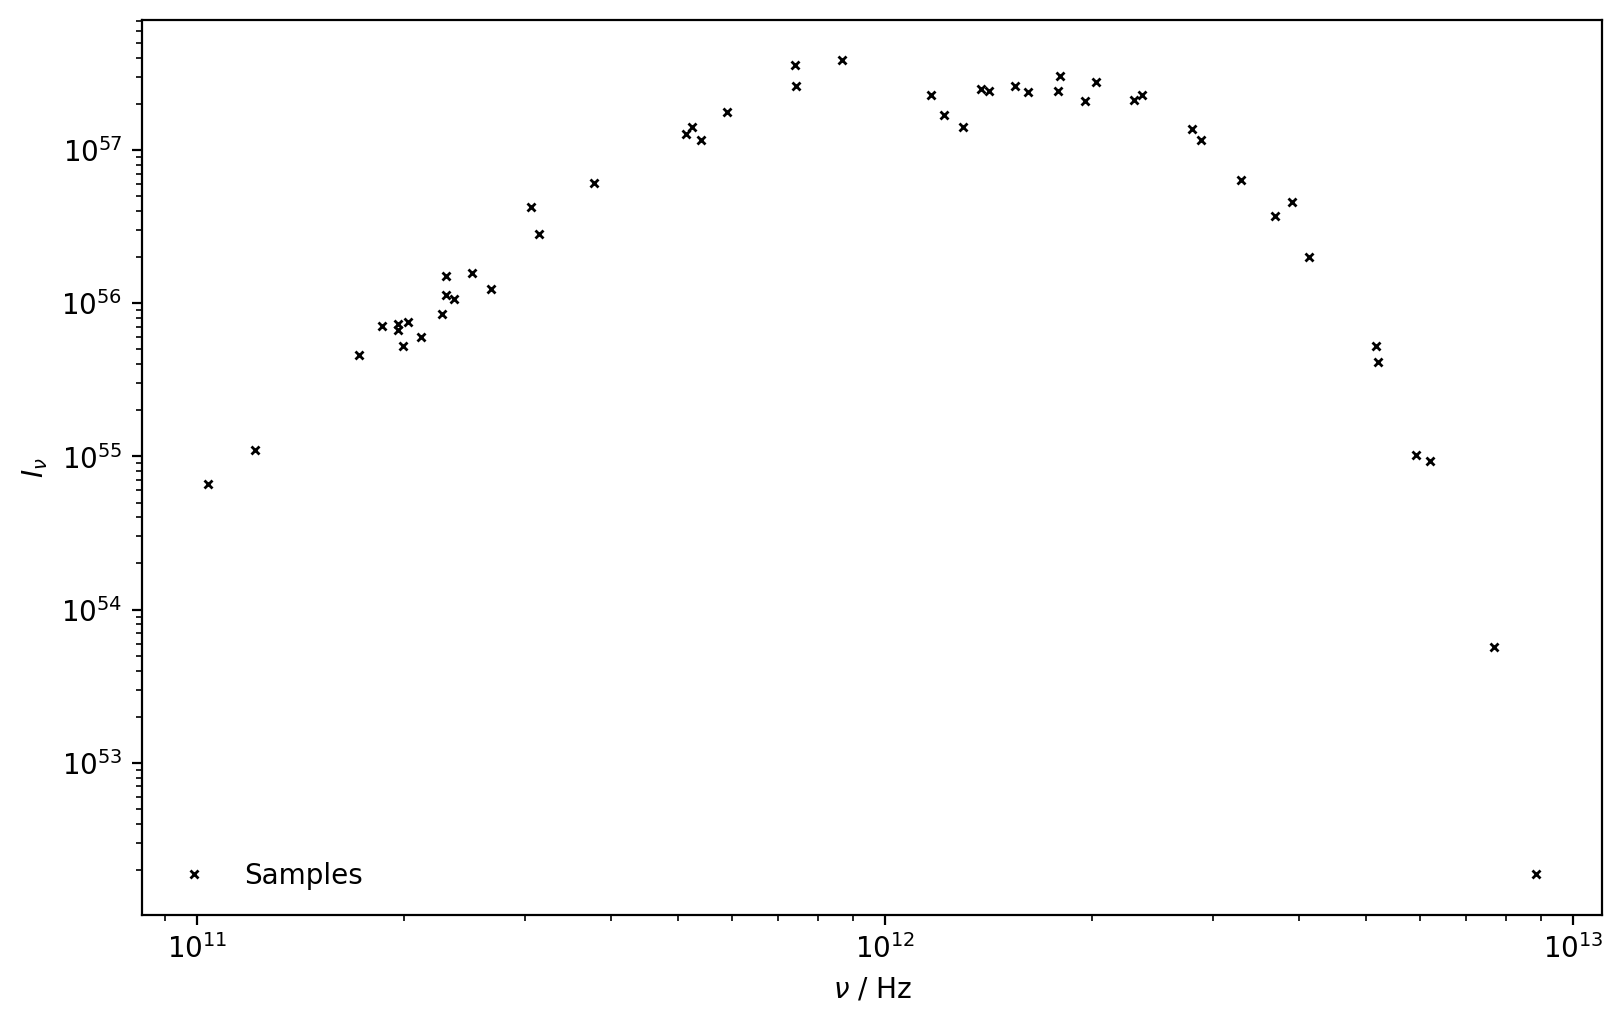

In [5]:
# Plot: Truth and Measurement

plt.plot(ff, II, 'kx', ms=3.21, label='Samples')

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$')

plt.xscale('log')
plt.yscale('log')

plt.legend(loc='lower left')

plt.savefig('wrong/measure.jpg', dpi=300)
plt.show()
plt.close()

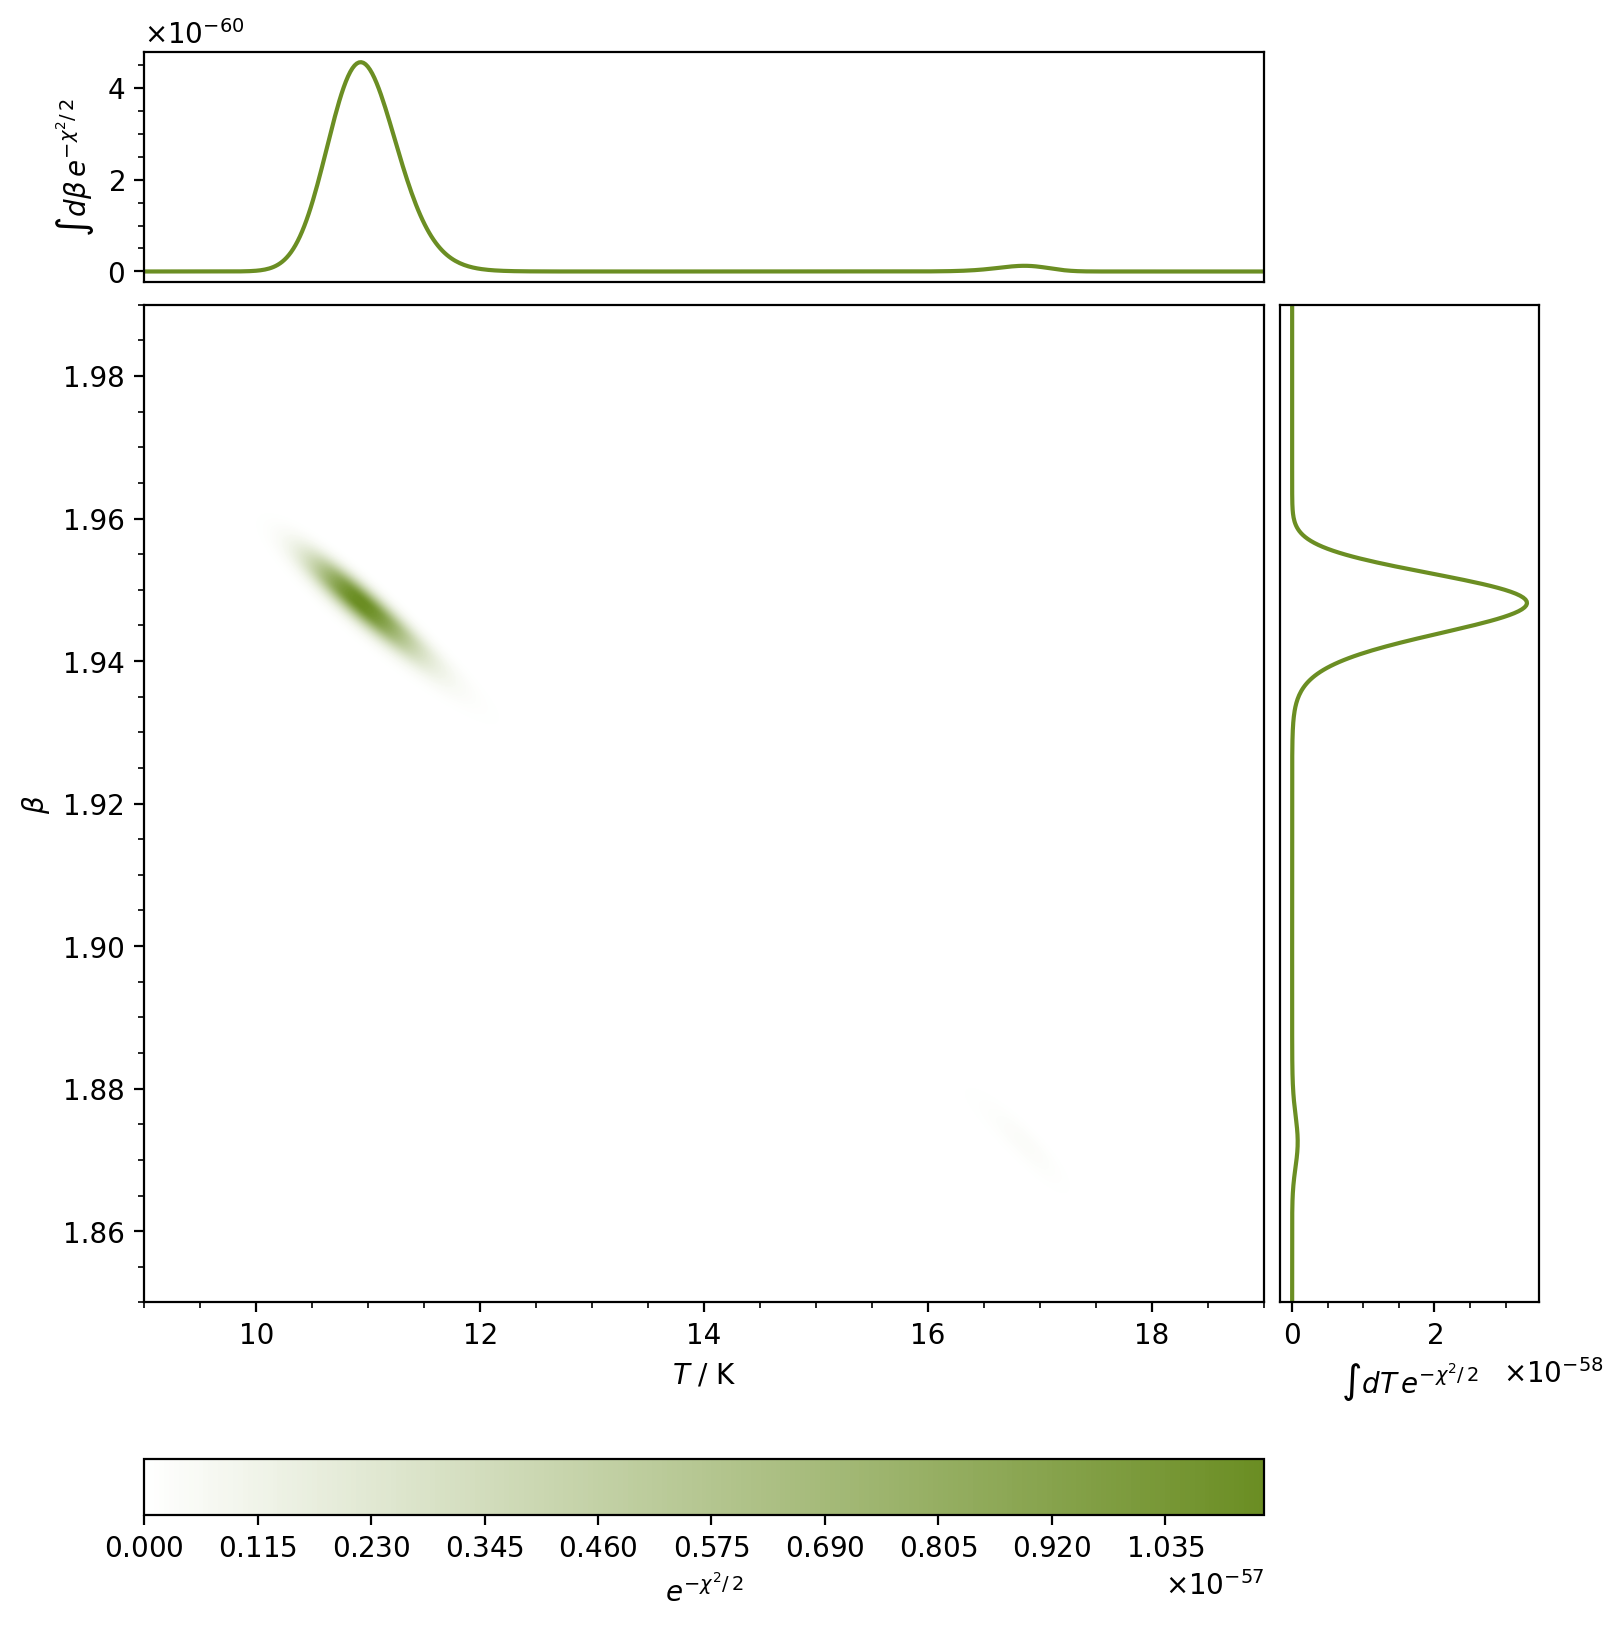

In [6]:
# Plot: Linear Likelihood

s = 512

X = np.linspace(9, 19, s) / 30.0
Y = np.linspace(1.85, 1.99, s)

X, Y = np.meshgrid(X, Y)

Z = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = chiSq(II, ff, uII, X[i, j], Y[i, j])

fig, ax = plt.subplots(2, 2, figsize=(8, 8), height_ratios=[1.5, 6.5], width_ratios=[6.5, 1.5])

cnt = ax[1,0].contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

cb = plt.colorbar(cnt, location='bottom')
cb.set_label(r'$e^{-\chi^2/\,2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

xlim = ax[1, 0].set_xlim()
ylim = ax[1, 0].set_ylim()

ax[1,0].set_xlabel(r'$T$ / K')
ax[1,0].set_ylabel(r'$\beta$')

ax[0, 1].axis('off')

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax[0,0].plot(30.0 * X[0,:], np.sum(np.exp(-Z / 2) * (Y[1, 0] - Y[0, 0]), axis=0))
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylabel(r'$\int d\beta \, e^{-\chi^2/\,2}$')
ax[0,0].get_xaxis().set_ticks([])
ax[0,0].yaxis.set_major_formatter(formatter)

ax[1,1].plot(np.sum(np.exp(-Z / 2) * 30.0 * (X[0, 1] - X[0, 0]), axis=1), Y[:,0])
ax[1,1].set_ylim(ylim)
ax[1,1].set_xlabel(r'$\int dT \, e^{-\chi^2/\,2}$')
ax[1,1].get_yaxis().set_ticks([])
ax[1,1].xaxis.set_major_formatter(formatter)

exp = ax[1,1].xaxis.get_offset_text()
cur = exp.get_position()
exp.set_position((cur[0] + 0.25, cur[1]))

plt.savefig('wrong/lin_like.jpg', dpi=300)
plt.show()
plt.close()

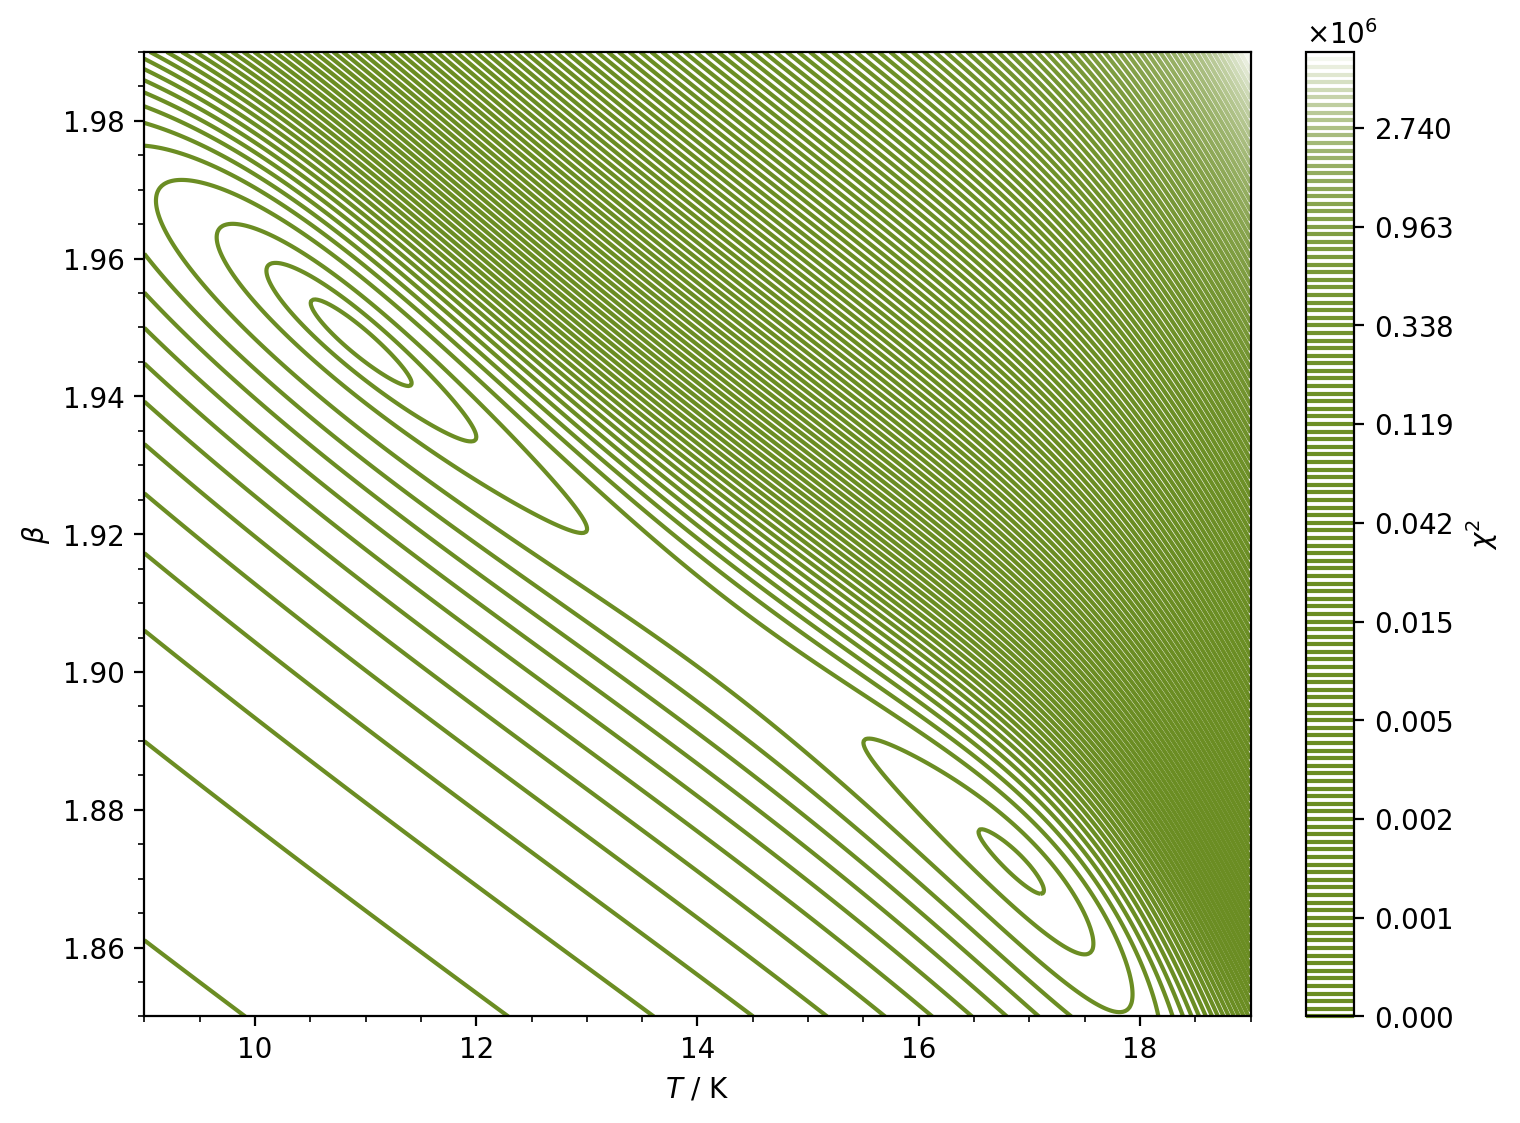

In [7]:
# Plot: Logarithmic Likelihood

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

lvl = np.logspace(np.log10(np.min(Z)), np.log10(np.max(Z)), 126)
lvl = np.insert(lvl, 1, lvl[0] + np.array([0.1, 0.4]) * (lvl[1] - lvl[0]))

cnt = ax.contour(30.0 * X, Y, Z, lvl, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.savefig('wrong/log_like.jpg', dpi=300)
plt.show()
plt.close()



initialization:   T = 13.00 K   ß = 1.860
  optimization:   T = 10.93 K   ß = 1.948
    iterations:   k = 2825


initialization:   T = 10.00 K   ß = 1.980
  optimization:   T = 10.93 K   ß = 1.948
    iterations:   k = 2471


initialization:   T = 15.50 K   ß = 1.920
  optimization:   T = 16.86 K   ß = 1.872
    iterations:   k = 1627


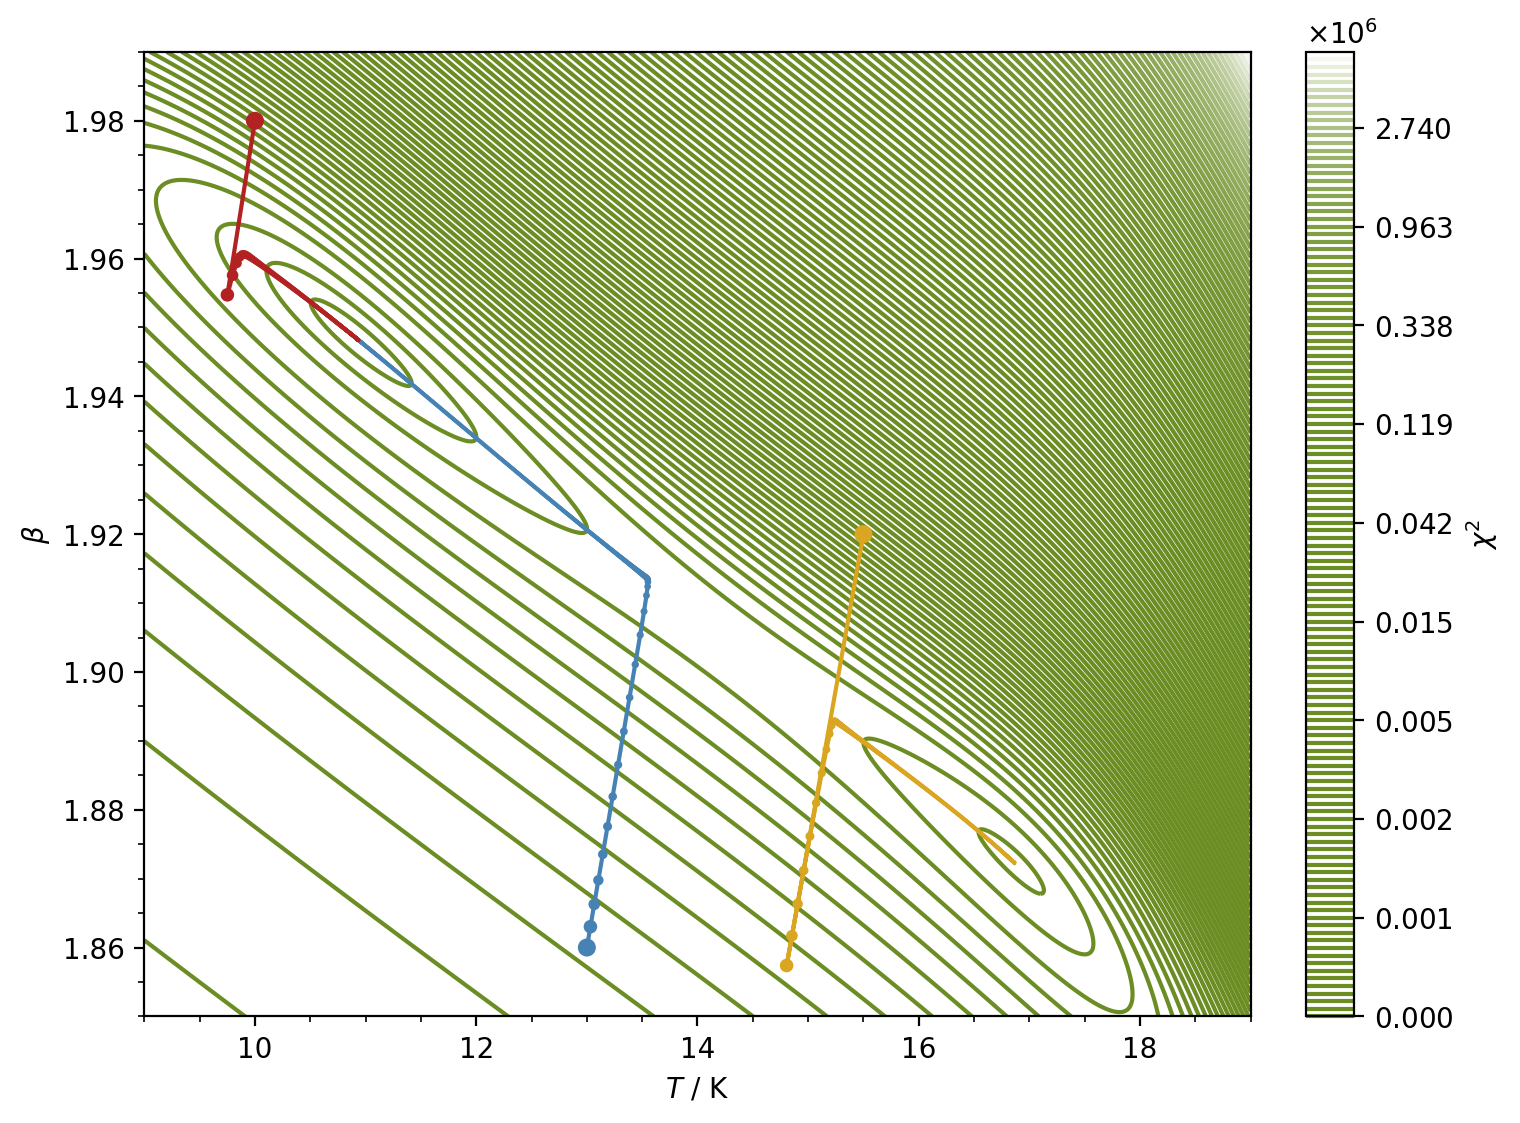

In [8]:
# Plot: Default Naive Gradient Descent

steps1, k1 = optGradDesc(II, ff, uII, 13.0, 1.86)
steps2, k2 = optGradDesc(II, ff, uII, 10.0, 1.98)
steps3, k3 = optGradDesc(II, ff, uII, 15.5, 1.92)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, lvl, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * steps1[:, 0], steps1[:, 1], s=(30 / (np.arange(k1 + 1) + 1)), zorder=10)
ax.plot(30.0 * steps1[:, 0], steps1[:, 1], zorder=10)

ax.scatter(30.0 * steps2[:, 0], steps2[:, 1], s=(30 / (np.arange(k2 + 1) + 1)), zorder=20)
ax.plot(30.0 * steps2[:, 0], steps2[:, 1], zorder=20)

ax.scatter(30.0 * steps3[:, 0], steps3[:, 1], s=(30 / (np.arange(k3 + 1) + 1)), zorder=30)
ax.plot(30.0 * steps3[:, 0], steps3[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.xlim(xlim)
plt.ylim(ylim)

plt.savefig('wrong/grad_desc.jpg', dpi=300)
plt.show()
plt.close()



initialization:   T = 13.00 K   ß = 1.860
  optimization:   T = 10.93 K   ß = 1.948
    iterations:   k = 388


initialization:   T = 10.00 K   ß = 1.980
  optimization:   T = 10.93 K   ß = 1.948
    iterations:   k = 311


initialization:   T = 15.50 K   ß = 1.920
  optimization:   T = 16.86 K   ß = 1.872
    iterations:   k = 234


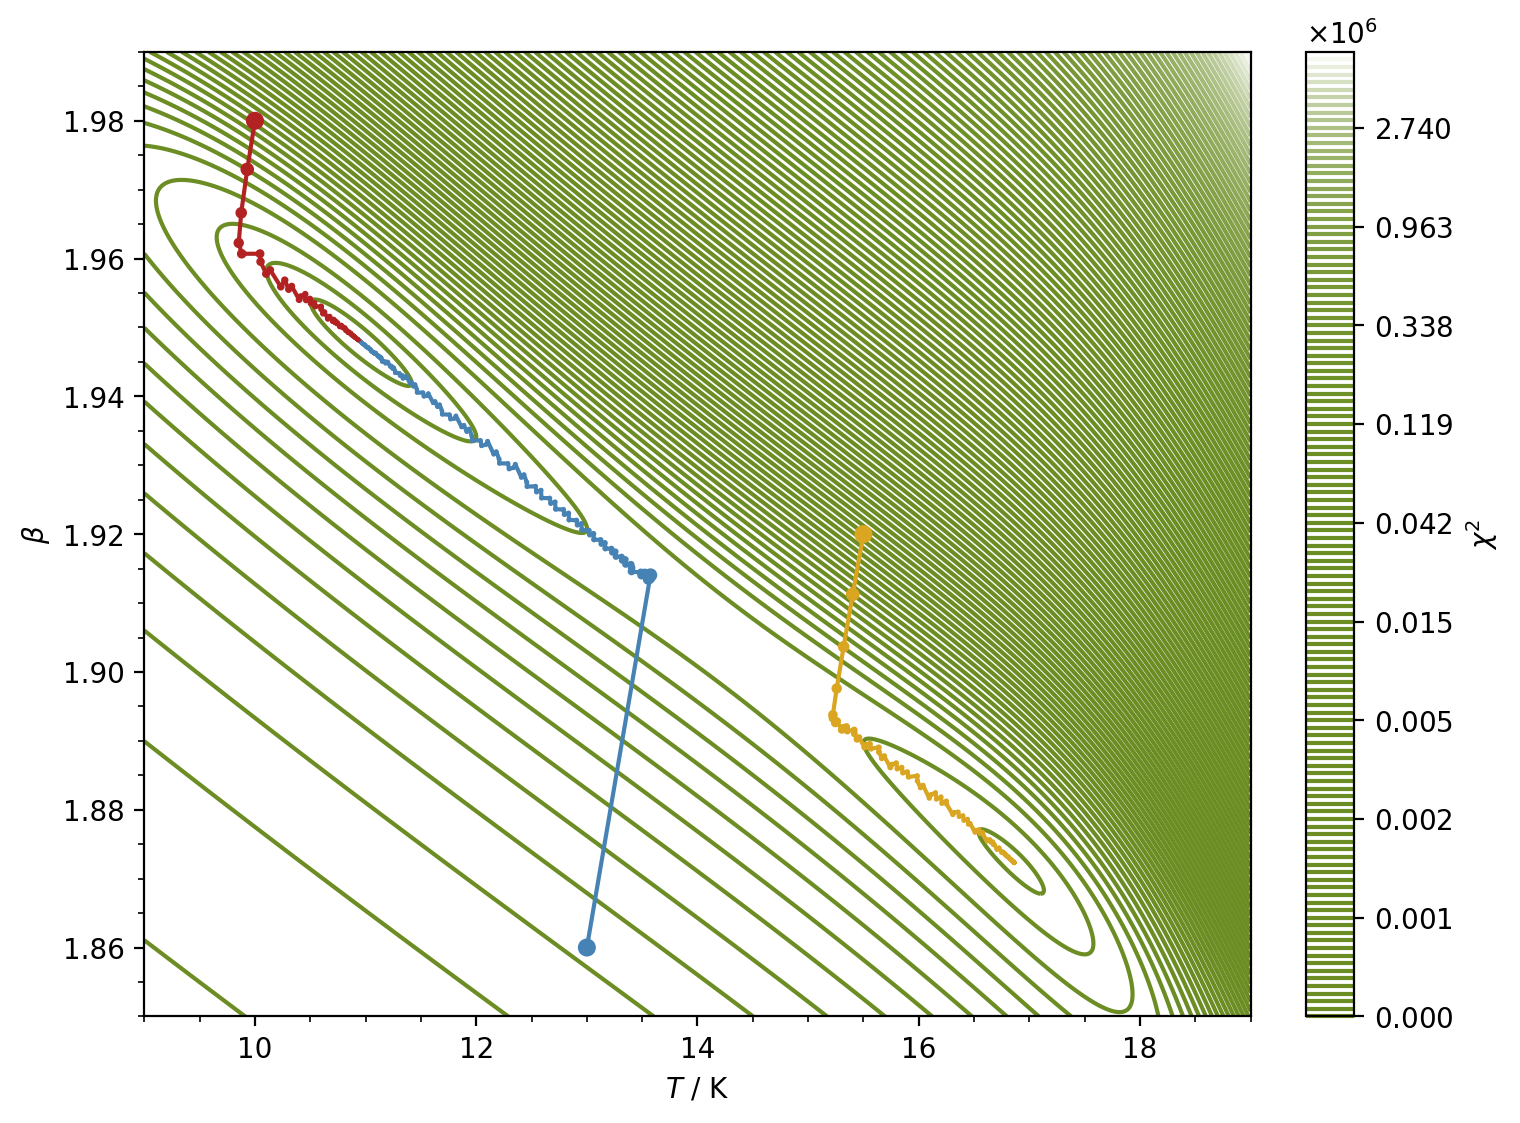

T = 10.93 & ß = 1.948 : χ = 16.19
T = 16.86 & ß = 1.872 : χ = 16.41


In [9]:
# Plot: Backtracking Line Search

steps4, k4, alpha4 = optGradDescLinSearch(II, ff, uII, 13.0, 1.86)
steps5, k5, alpha5 = optGradDescLinSearch(II, ff, uII, 10.0, 1.98)
steps6, k6, alpha6 = optGradDescLinSearch(II, ff, uII, 15.5, 1.92)

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contour(30.0 * X, Y, Z, lvl, cmap=OliveDrab, zorder=-1)

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$\chi^2$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.scatter([], [])
ax.plot([], [])

ax.scatter(30.0 * steps4[:, 0], steps4[:, 1], s=(30 / (np.arange(k4 + 1) + 1)), zorder=10)
ax.plot(30.0 * steps4[:, 0], steps4[:, 1], zorder=10)

ax.scatter(30.0 * steps5[:, 0], steps5[:, 1], s=(30 / (np.arange(k5 + 1) + 1)), zorder=20)
ax.plot(30.0 * steps5[:, 0], steps5[:, 1], zorder=20)

ax.scatter(30.0 * steps6[:, 0], steps6[:, 1], s=(30 / (np.arange(k6 + 1) + 1)), zorder=30)
ax.plot(30.0 * steps6[:, 0], steps6[:, 1], zorder=30)

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.savefig('wrong/grad_desc_lin_sear.jpg', dpi=300)
plt.show()
plt.close()

print(f'T = {30.0 * (steps4[-1, 0] + steps5[-1, 0]) / 2 :.2f} & \
ß = {(steps4[-1, 1] + steps5[-1, 1]) / 2 :.3f} : \
χ = {np.sqrt(chiSq(II, ff, uII, *(steps4[-1, :] + steps5[-1, :]) / 2)):.2f}')

print(f'T = {30.0 * steps6[-1, 0] :.2f} & \
ß = {steps6[-1, 1] :.3f} : \
χ = {np.sqrt(chiSq(II, ff, uII, *steps6[-1, :])):.2f}')

par = (steps4[-1, :] + steps5[-1, :]) / 2
minChiSq = chiSq(II, ff, uII, *par)

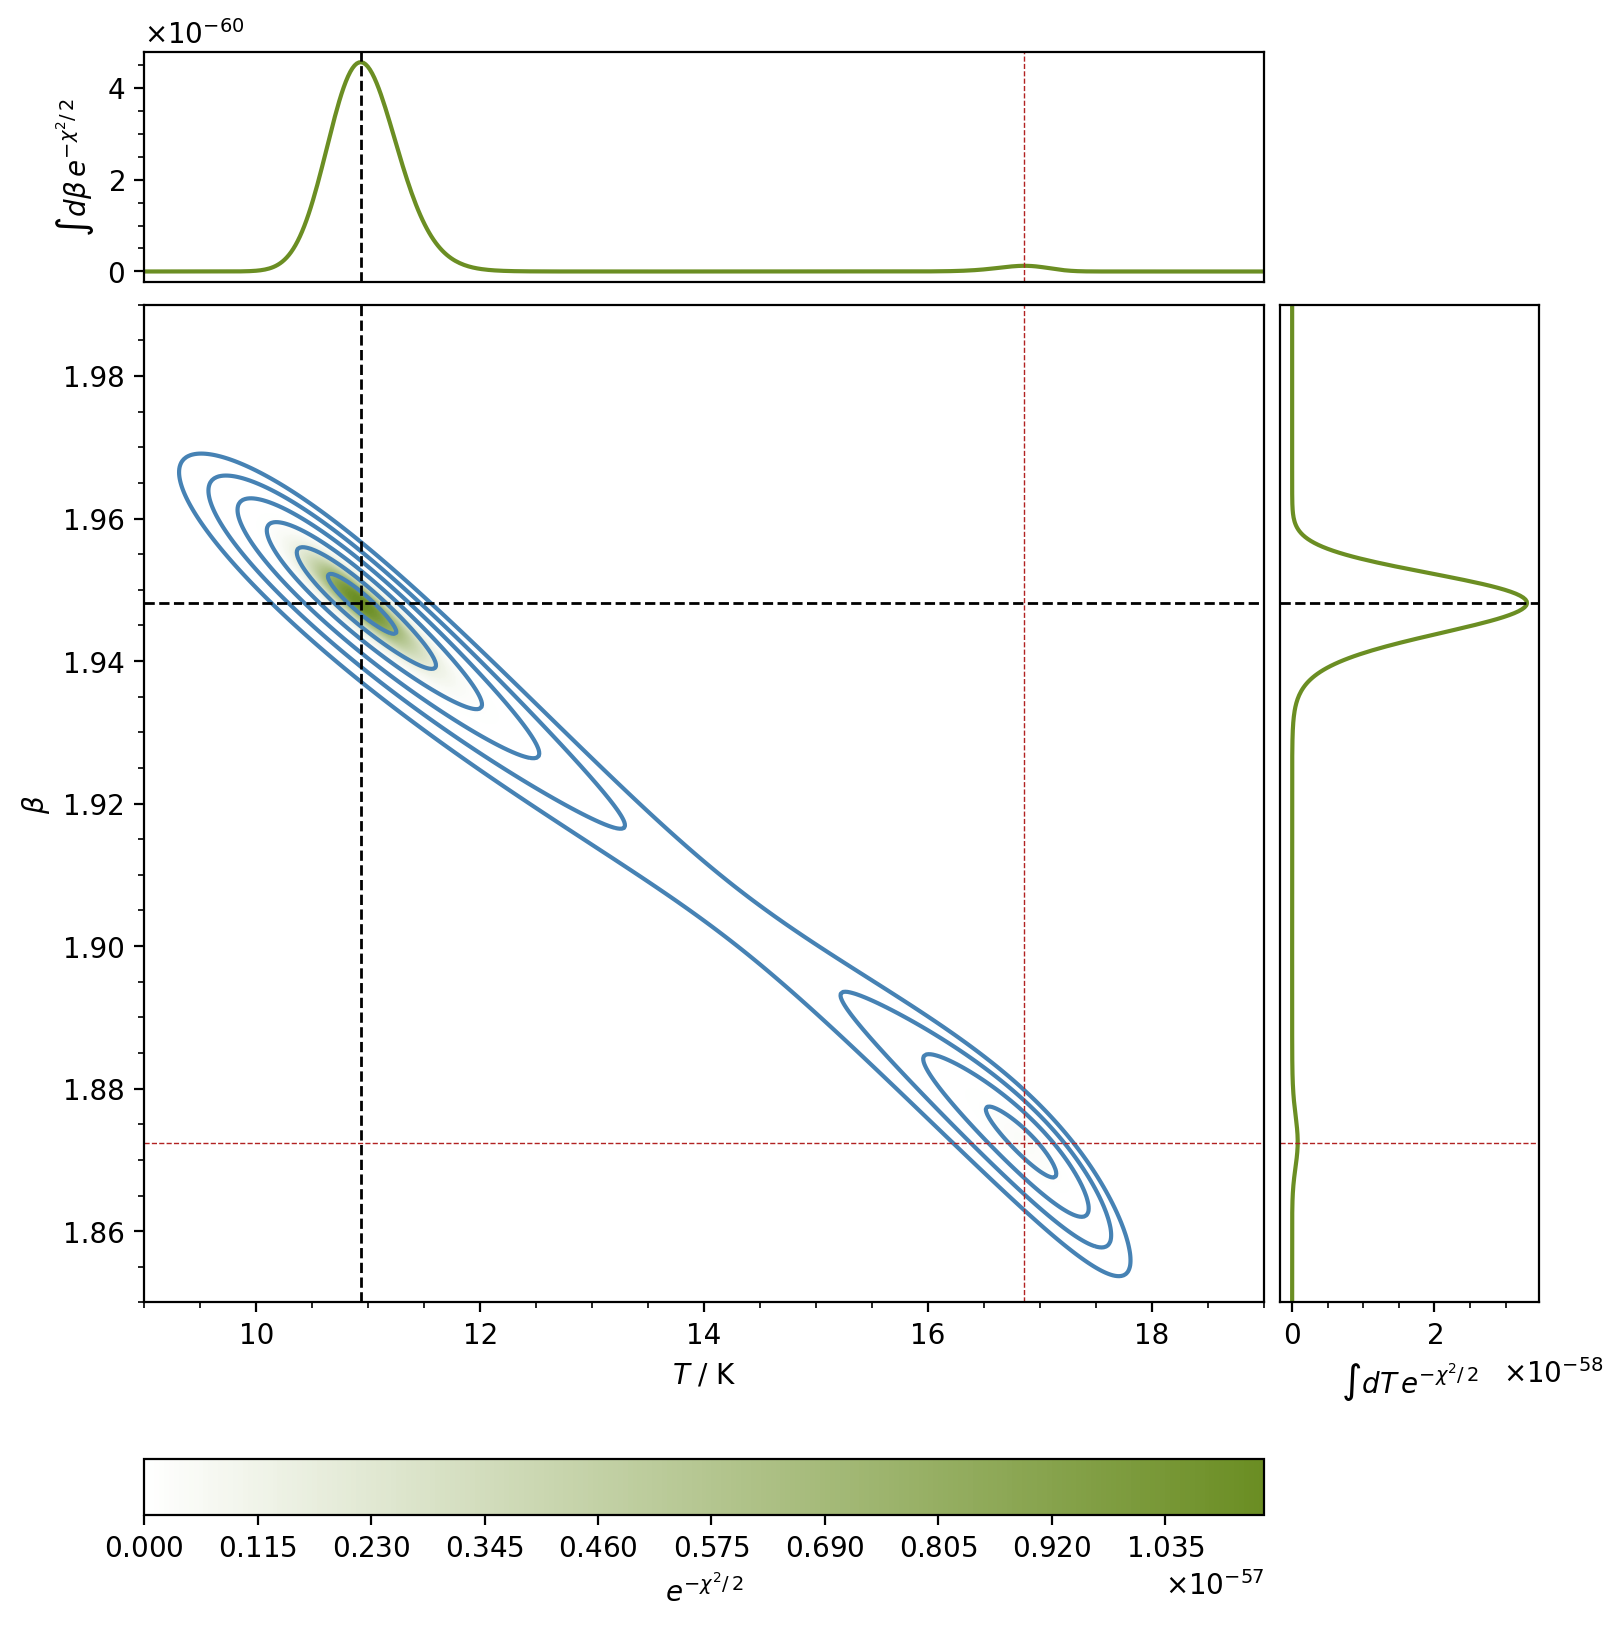

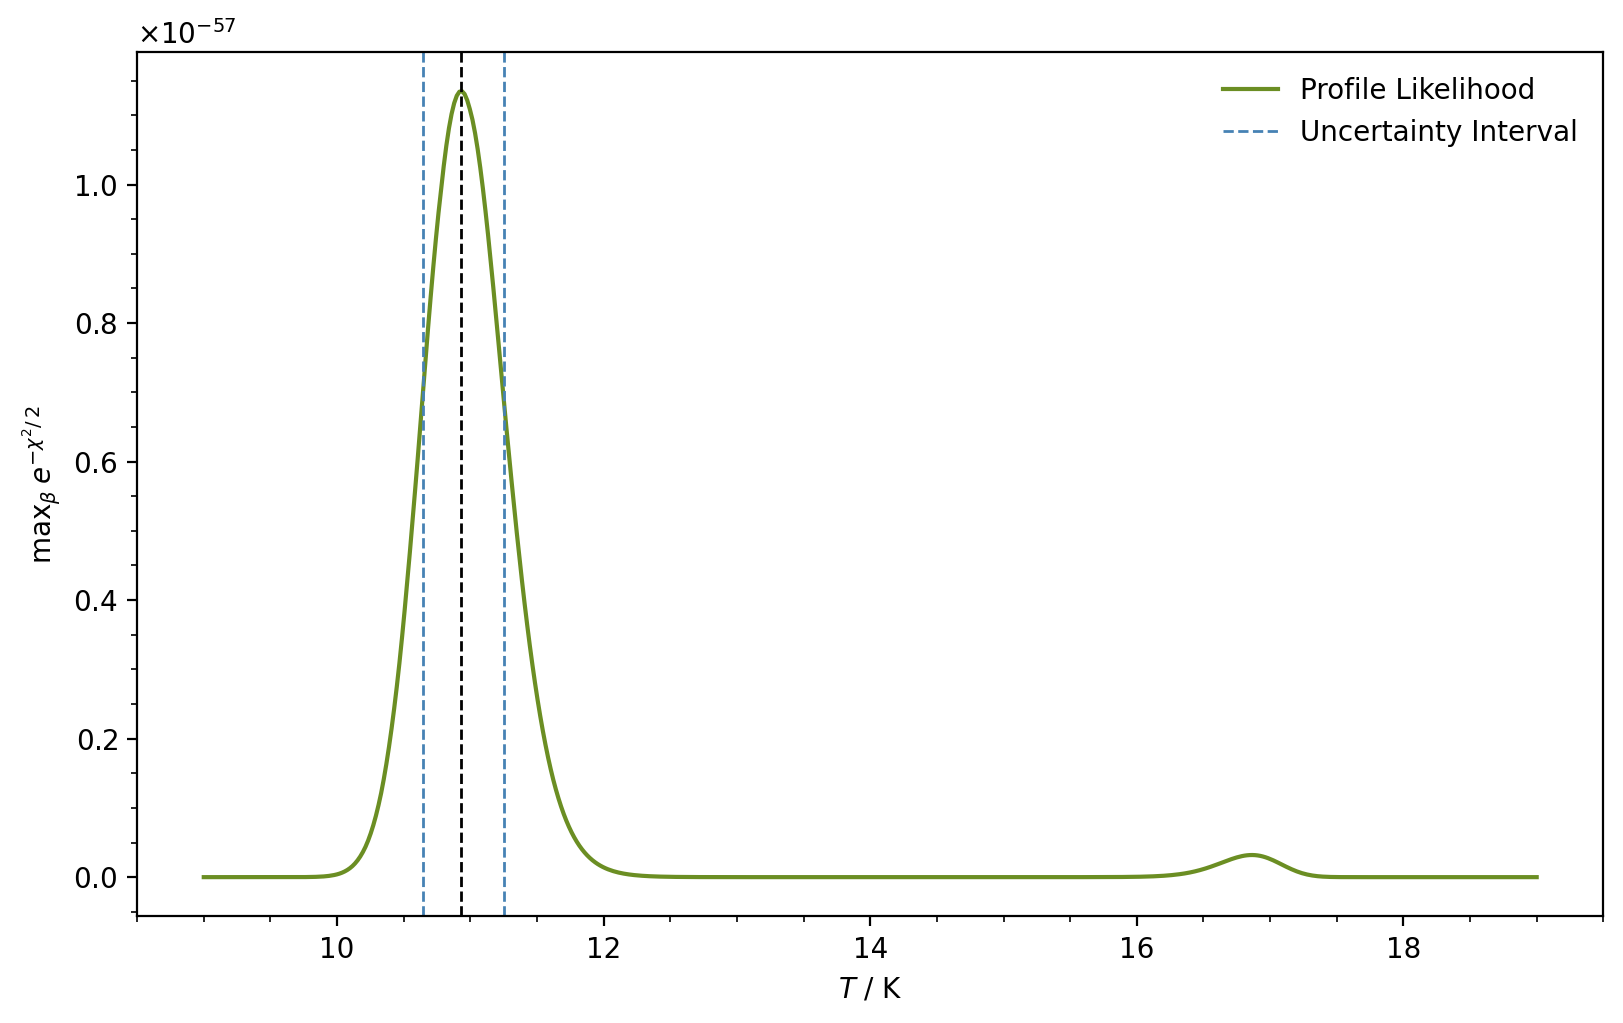

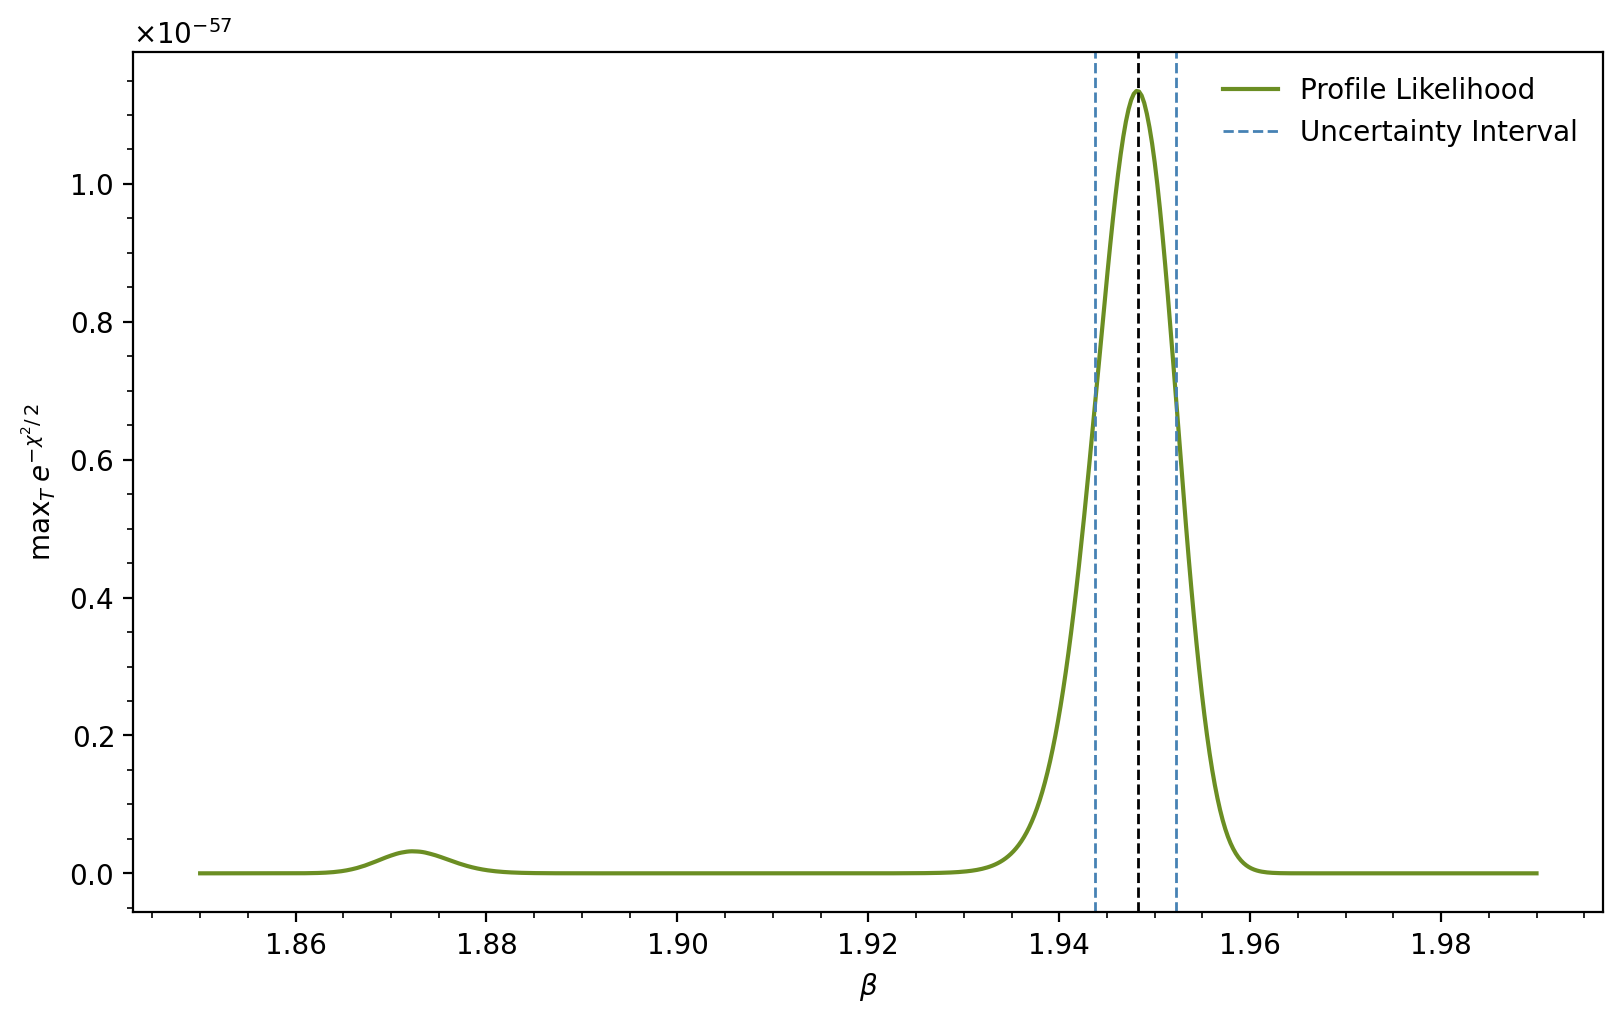

T = 10.93(+0.32)(-0.29) K
ß = 1.9482(+0.0040)(-0.0045)


In [10]:
# Plot: Sigma Contours and Profiled Distributions

fig, ax = plt.subplots(2, 2, figsize=(8, 8), height_ratios=[1.5, 6.5], width_ratios=[6.5, 1.5])

cnt = ax[1,0].contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

cb = plt.colorbar(cnt, location='bottom')
cb.set_label(r'$e^{-\chi^2/\,2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax[1,0].contour(30 * X, Y, Z, levels=[minChiSq + 1.0, minChiSq + 4.0, minChiSq + 9.0, minChiSq + 16.0, minChiSq + 25.0, minChiSq + 36.0], colors='steelblue')

ax[1,0].axvline(30.0 * par[0], c='k', ls='--', lw=1.0)
ax[1,0].axhline(par[1], c='k', ls='--', lw=1.0)

ax[1,0].axvline(30.0 * steps6[-1, 0], c='firebrick', ls='--', lw=0.5)
ax[1,0].axhline(steps6[-1, 1], c='firebrick', ls='--', lw=0.5)

xlim = ax[1, 0].set_xlim()
ylim = ax[1, 0].set_ylim()

ax[1,0].set_xlabel(r'$T$ / K')
ax[1,0].set_ylabel(r'$\beta$')

ax[0, 1].axis('off')

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax[0,0].plot(30.0 * X[0,:], np.sum(np.exp(-Z / 2) * (Y[1, 0] - Y[0, 0]), axis=0))
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylabel(r'$\int d\beta \, e^{-\chi^2/\,2}$')
ax[0,0].get_xaxis().set_ticks([])
ax[0,0].yaxis.set_major_formatter(formatter)
ax[0,0].axvline(30.0 * par[0], c='k', ls='--', lw=1.0)
ax[0,0].axvline(30.0 * steps6[-1, 0], c='firebrick', ls='--', lw=0.5)

ax[1,1].plot(np.sum(np.exp(-Z / 2) * 30.0 * (X[0, 1] - X[0, 0]), axis=1), Y[:,0])
ax[1,1].set_ylim(ylim)
ax[1,1].set_xlabel(r'$\int dT \, e^{-\chi^2/\,2}$')
ax[1,1].get_yaxis().set_ticks([])
ax[1,1].xaxis.set_major_formatter(formatter)
ax[1,1].axhline(par[1], c='k', ls='--', lw=1.0)
ax[1,1].axhline(steps6[-1, 1], c='firebrick', ls='--', lw=0.5)

exp = ax[1,1].xaxis.get_offset_text()
cur = exp.get_position()
exp.set_position((cur[0] + 0.25, cur[1]))

plt.savefig('wrong/lin_like_cont.jpg', dpi=300)
plt.show()
plt.close()

profX = np.min(Z, axis=0)
profY = np.min(Z, axis=1)

minArgProfX = np.argmin(profX)
minArgProfY = np.argmin(profY)

leftArgX = np.argmin(np.abs(profX[:minArgProfX] - minChiSq - 1.0))
rightArgX = np.argmin(np.abs(profX[minArgProfX:] - minChiSq - 1.0)) + minArgProfX

leftArgY = np.argmin(np.abs(profY[:minArgProfY] - minChiSq - 1.0))
rightArgY = np.argmin(np.abs(profY[minArgProfY:] - minChiSq - 1.0)) + minArgProfY

leftSigX = 30.0 * X[0, leftArgX]
rightSigX = 30.0 * X[0, rightArgX]

leftSigY = Y[leftArgY, 0]
rightSigY = Y[rightArgY, 0]

plt.plot(30.0 * X[0, :], np.exp(-profX / 2), label='Profile Likelihood')
plt.axvline(30.0 * par[0], c='k', ls='--', lw=1.0)

plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel(r'$T$ / K')
plt.ylabel(r'max$_\beta\:e^{-\chi^2/\,2}$')
plt.axvline(leftSigX, c='steelblue', ls='--', lw=1.0)
plt.axvline(rightSigX, c='steelblue', ls='--', lw=1.0, label='Uncertainty Interval')

plt.legend(loc='upper right')

plt.savefig('wrong/prof_like_T.jpg', dpi=300)
plt.show()
plt.close()

plt.plot(Y[:, 0], np.exp(-profY / 2), label='Profile Likelihood')
plt.axvline(par[1], c='k', ls='--', lw=1.0)
plt.axvline(leftSigY, c='steelblue', ls='--', lw=1.0)
plt.axvline(rightSigY, c='steelblue', ls='--', lw=1.0, label='Uncertainty Interval')

plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel(r'$\beta$')
plt.ylabel(r'max$_T\:e^{-\chi^2/\,2}$')

plt.legend(loc='upper right')

plt.savefig('wrong/prof_like_b.jpg', dpi=300)
plt.show()
plt.close()

print(f'T = {30.0 * par[0]:.2f}(+{(rightSigX - 30.0 * par[0]):.2f})(-{(30.0 * par[0] - leftSigX):.2f}) K')
print(f'ß = {par[1]:.4f}(+{(rightSigY - par[1]):.4f})(-{(par[1] - leftSigY):.4f})')

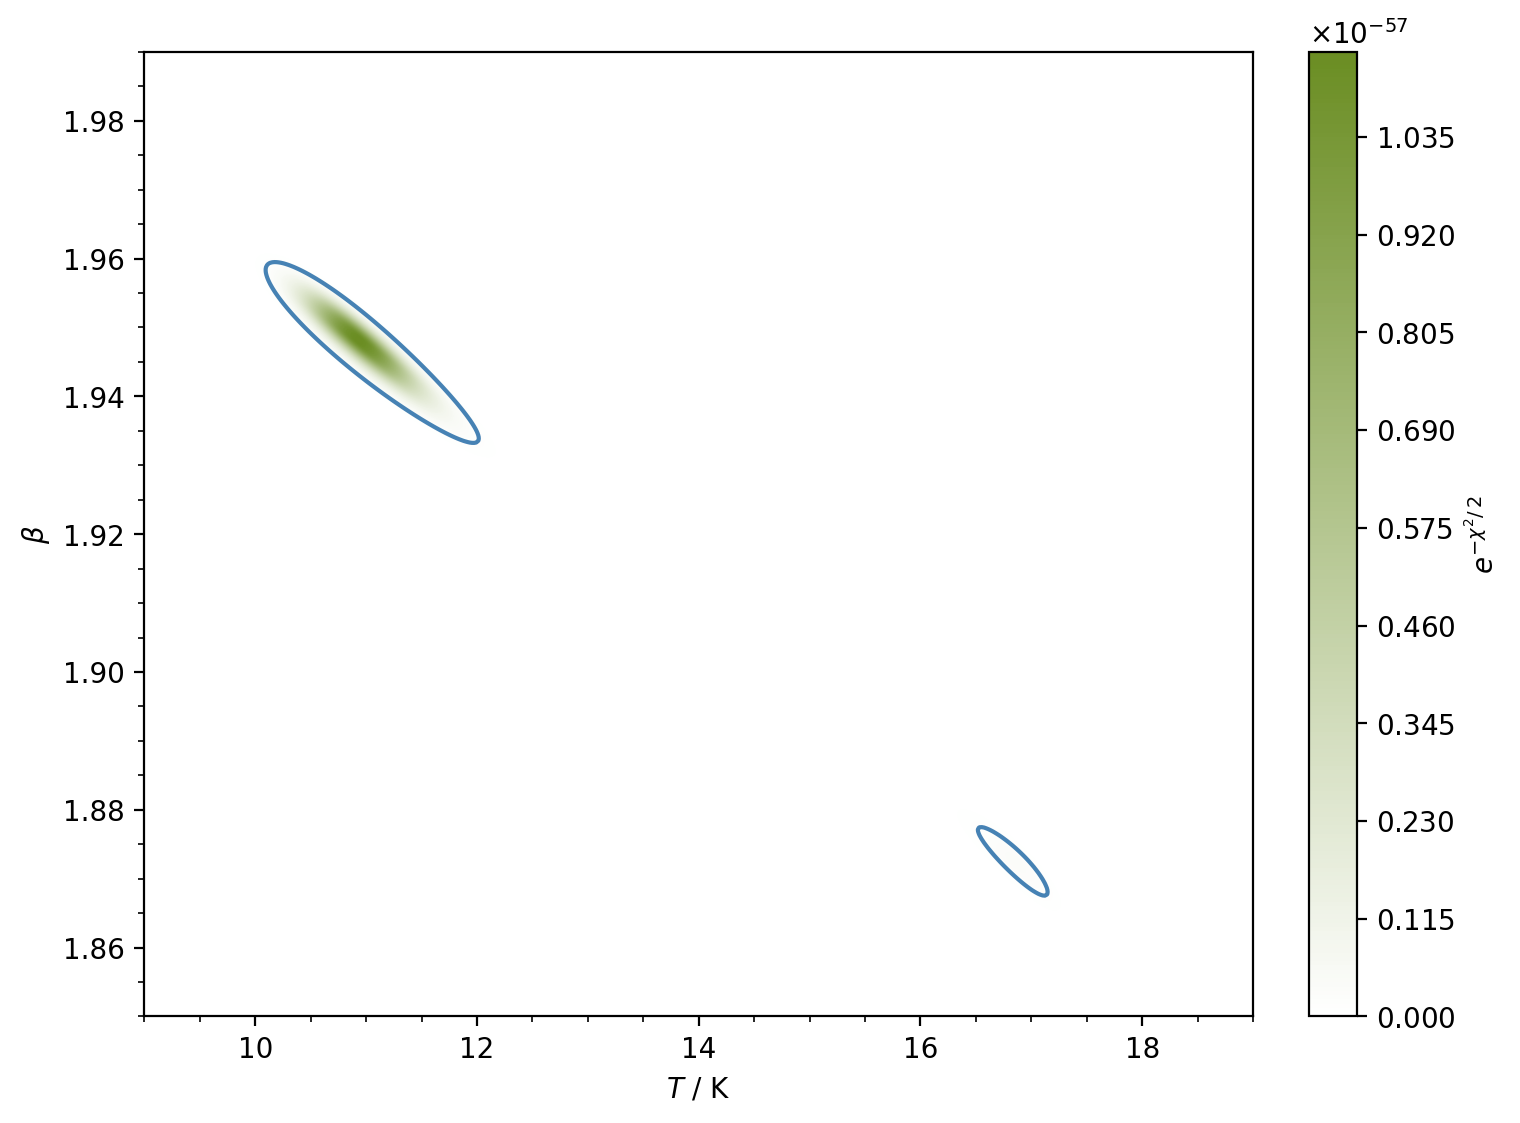

In [11]:
plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contourf(30.0 * X, Y, np.exp(-Z/2), 256, cmap=OliveDrab_r)
cnt.set_edgecolor('face')

ax.contour(30 * X, Y, Z, levels=[minChiSq + 9.0], colors='steelblue')

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$e^{- \chi^2/\, 2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.savefig('wrong/lin_like_comp.jpg', dpi=300)
plt.show()
plt.close()

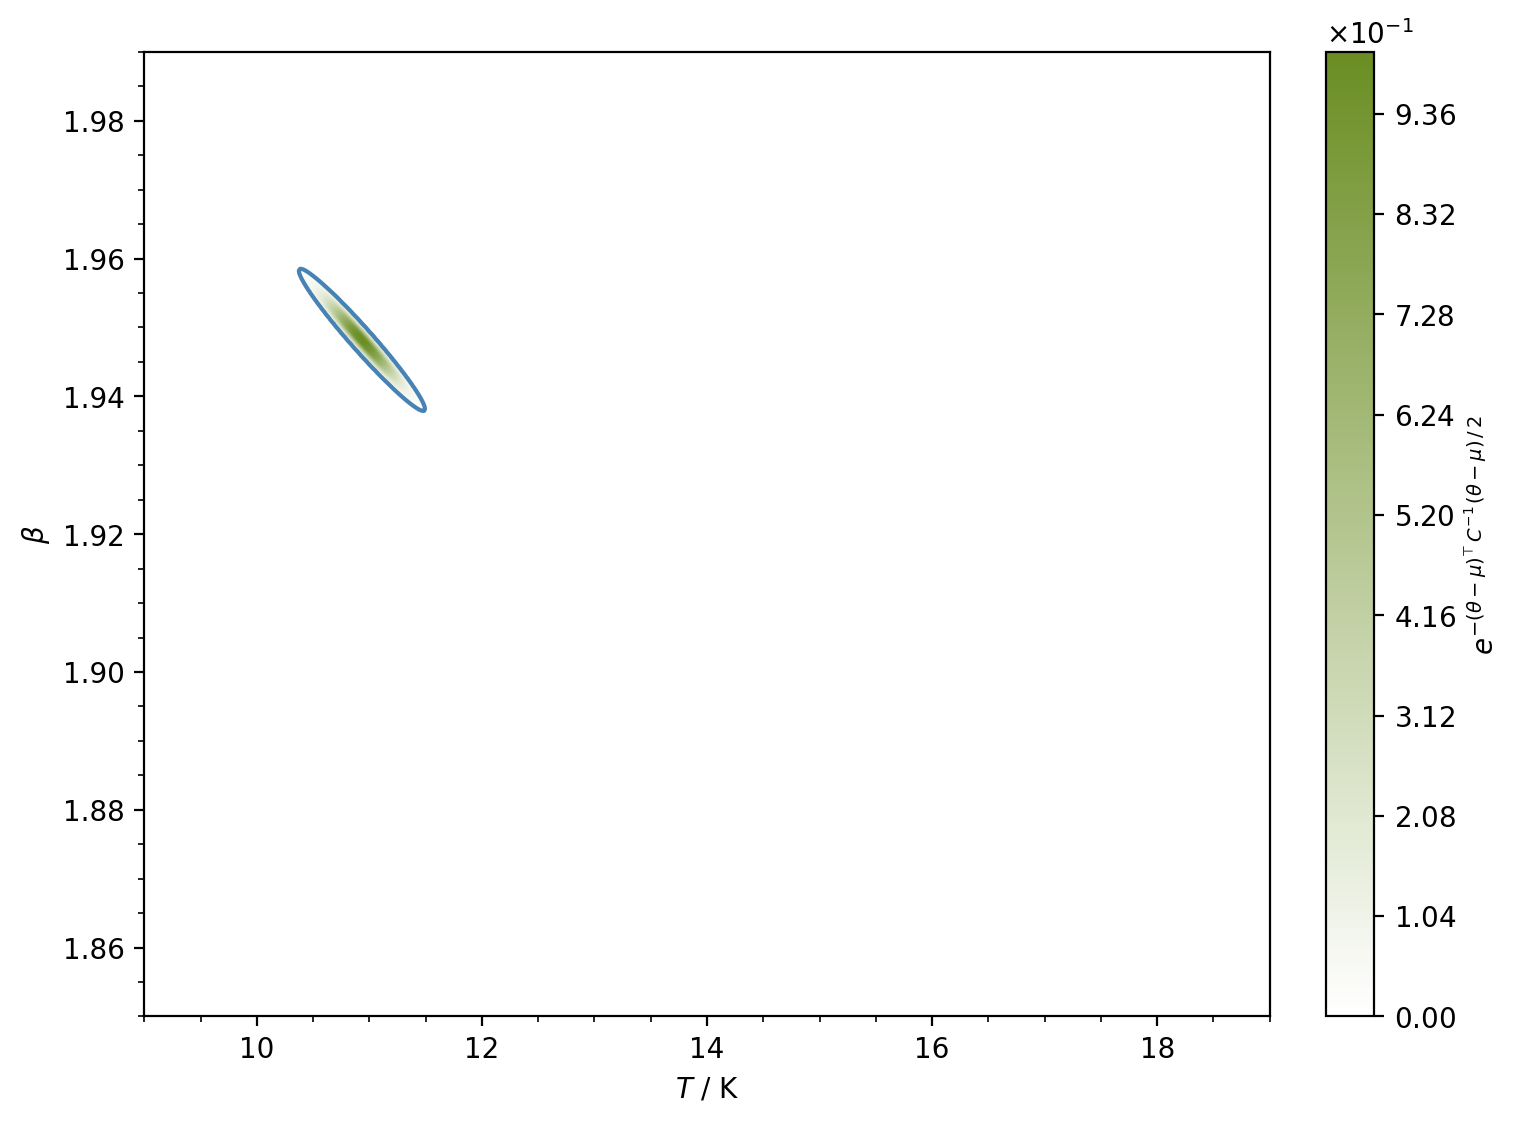

    ┌────────────┬────────────┐
    │ +0.0349519 │ -0.0006262 │
C = ├────────────┼────────────┤
    │ -0.0006262 │ +0.0000119 │
    └────────────┴────────────┘


In [12]:
G = np.array([logLike_TGrad(II, ff, uII, *par) / 30.0, logLike_bGrad(II, ff, uII, *par)])
C = np.linalg.inv(G @ G.T)

cov = C.copy()
cov[0,0] /= 30.0**2
cov[0,1] /= 30.0
cov[1,0] /= 30.0

U = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        U[i, j] = gaussian(par, cov, X[i, j], Y[i, j])

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contourf(30.0 * X, Y, U, 256, cmap=OliveDrab_r, zorder=-1)
cnt.set_edgecolor('face')

ax.contour(30 * X, Y, U, levels=[np.exp(-4.5)], colors='steelblue')

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$e^{- (\theta - \mu)^{\!\top}C^{-1\,}(\theta - \mu) \,/\, 2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.savefig('wrong/lin_like_comp_fisher.jpg', dpi=300)
plt.show()
plt.close()

print('    ┌────────────┬────────────┐')
print(f'    │ +{C[0,0]:.7f} │ {C[0,1]:.7f} │')
print('C = ├────────────┼────────────┤')
print(f'    │ {C[1,0]:.7f} │ +{C[1,1]:.7f} │')
print('    └────────────┴────────────┘')

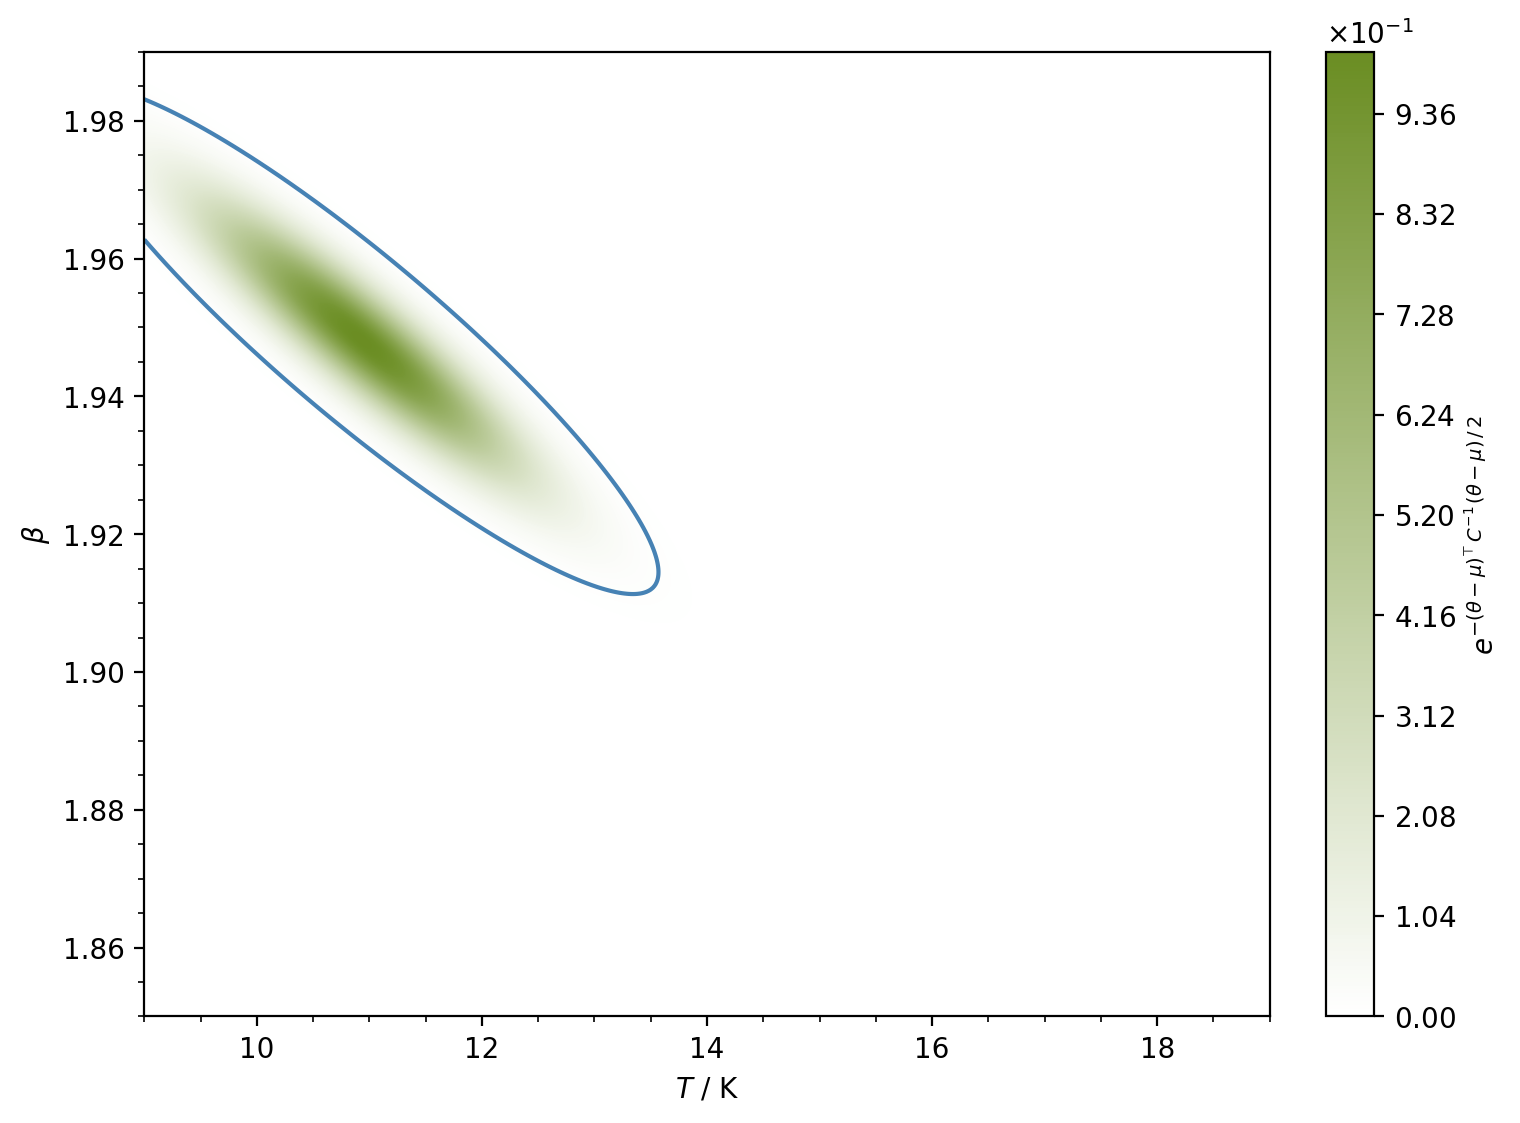

    ┌───────────┬───────────┐
    │ +0.771670 │ -0.009873 │
C = ├───────────┼───────────┤
    │ -0.009873 │ +0.000151 │
    └───────────┴───────────┘


In [13]:
intX, intY = X, Y

intZ = np.exp(- Z / 2)

norm = np.sum(np.sum(intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0]))

TExpect = np.sum(np.sum(intX[0, :] * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm
bExpect = np.sum(np.sum(intY[:, 0] * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm

TVar = np.sum(np.sum((intX[0, :] - TExpect)**2 * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm
bVar = np.sum(np.sum((intY[:, 0] - bExpect)**2 * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm

bTCov = np.sum(np.sum((intX - TExpect) * (intY - bExpect) * intZ * (intY[1, 0] - intY[0, 0]), axis=0) * (intX[0, 1] - intX[0, 0])) / norm

C = np.array([[TVar * 30.0**2, bTCov * 30.0], [bTCov * 30.0, bVar]])

cov = np.array([[TVar, bTCov], [bTCov, bVar]])

V = np.zeros(X.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        V[i, j] = gaussian(par, cov, X[i, j], Y[i, j])

plt.fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))

cnt = ax.contourf(30.0 * X, Y, V, 256, cmap=OliveDrab_r, zorder=-1)
cnt.set_edgecolor('face')

ax.contour(30 * X, Y, V, levels=[np.exp(-4.5)], colors='steelblue')

cb = plt.colorbar(cnt, location='right')
cb.set_label(r'$e^{- (\theta - \mu)^{\!\top}C^{-1\,}(\theta - \mu) \,/\, 2}$')
cb.formatter.set_powerlimits((0, 0))
cb.formatter.set_useMathText(True)
cb.ax.yaxis.set_offset_position('left')

ax.set_xlabel(r'$T$ / K')
ax.set_ylabel(r'$\beta$')

plt.savefig('wrong/lin_like_comp_integral.jpg', dpi=300)
plt.show()
plt.close()

print('    ┌───────────┬───────────┐')
print(f'    │ +{C[0,0]:.6f} │ {C[0,1]:.6f} │')
print('C = ├───────────┼───────────┤')
print(f'    │ {C[1,0]:.6f} │ +{C[1,1]:.6f} │')
print('    └───────────┴───────────┘')

In [14]:
# Data: Generate Test Chains

ll = 50000

chain, ac = metroMCMC(ll, 13.0, 1.86, II, ff, uII, h = 0.005)

TSamp = 30.0 * chain[:, 0]
bSamp = chain[:, 1]

TMean = np.mean(TSamp)
bMean = np.mean(bSamp)

done:   generated 50000 samples after 155130 evaluations with acceptance ratio 32.23%


In [15]:
# Data: Generate Autocorrelation

TAcorr, TAerr, ttt = autoCorrCoeff(TSamp[10000:], 100, 1000)

bAcorr, bAerr, ttt = autoCorrCoeff(bSamp[10000:], 100, 1000)

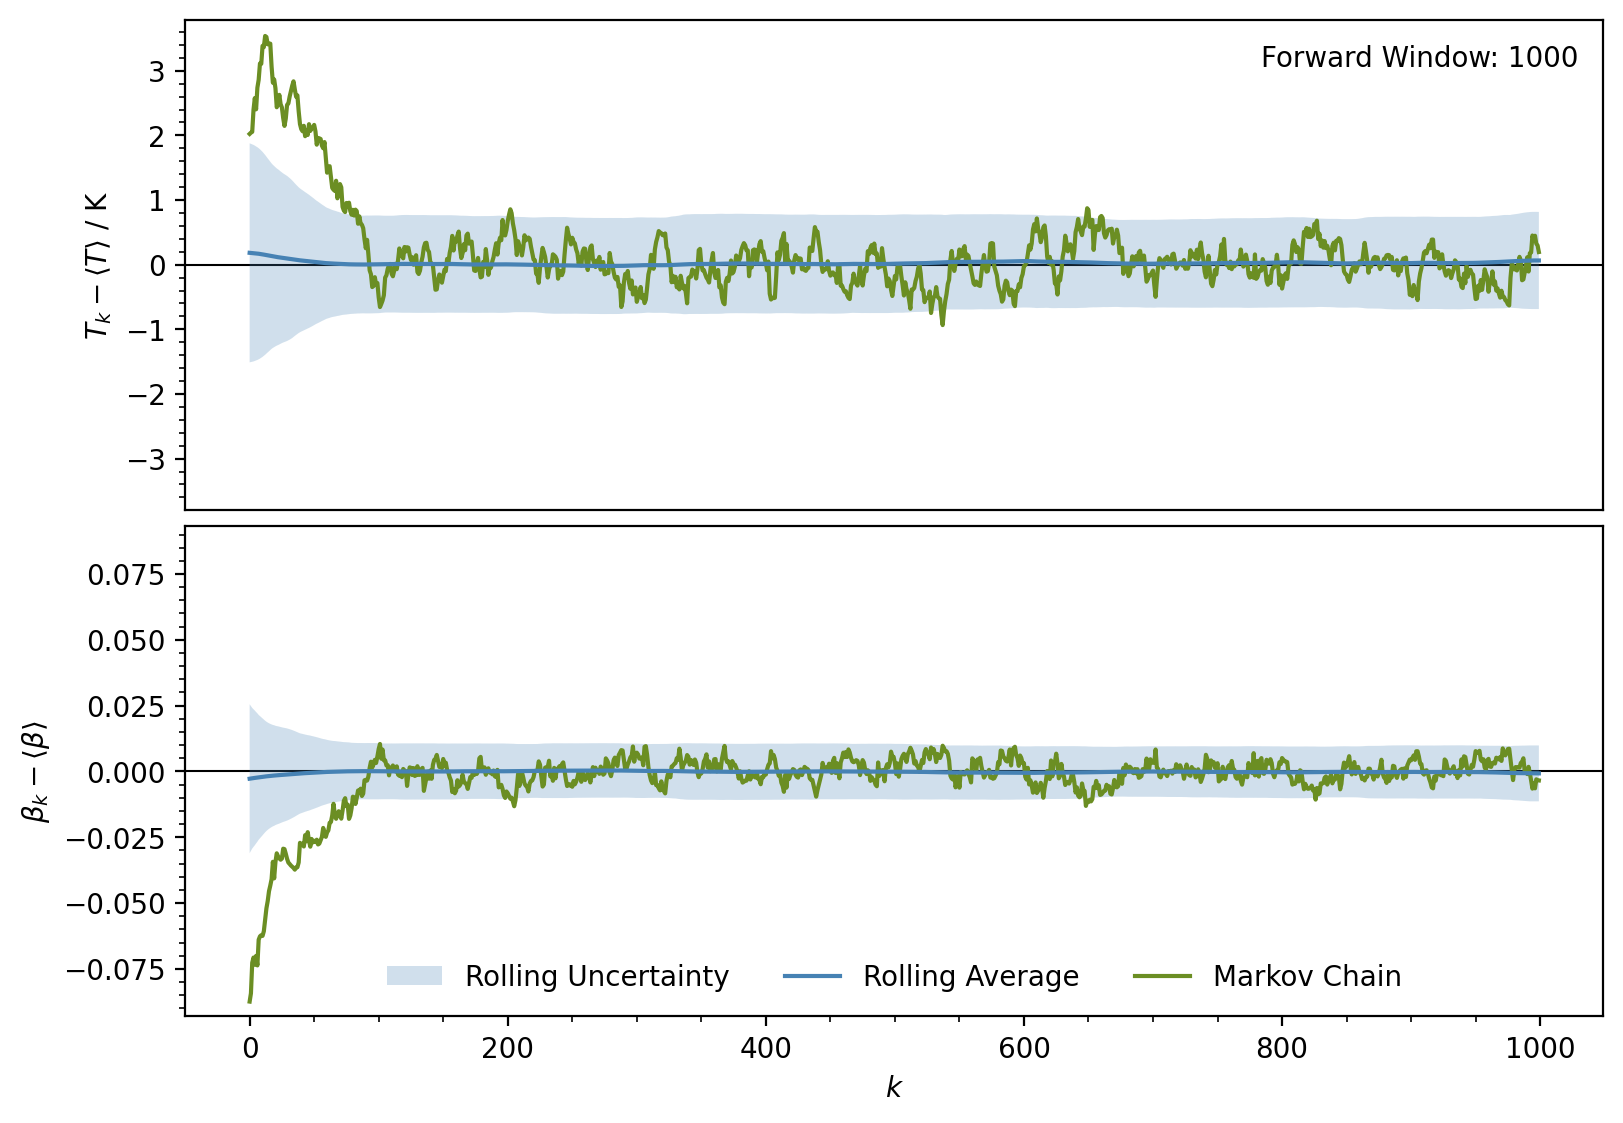

In [16]:
# Plot: Burn In and Rolling Averages

leng = 1000
win = 1000
ind = np.arange(leng)

T_sam = TSamp[:leng] - TMean
T_rMean = rollMean(TSamp - TMean, win)[:leng]
T_rUnc = rollUnc(TSamp - TMean, win)[:leng]

b_sam = bSamp[:leng] - bMean
b_rMean = rollMean(bSamp - bMean, win)[:leng]
b_rUnc = rollUnc(bSamp - bMean, win)[:leng]

fig, ax = plt.subplots(2, 1, figsize=(8, 5.5))

ax[0].fill_between(ind, T_rMean - 2.5 * T_rUnc, T_rMean + 2.5 * T_rUnc, color='steelblue', edgecolor='none', alpha=0.25)

ax[0].plot(ind, T_sam)
ax[0].plot(ind, T_rMean)

ax[0].axhline(0, c='k', lw=0.75, zorder=-1)

ax[0].set_ylabel(r'$T_k - \langle T\rangle$ / K')

ax[0].set_ylim(-ax[0].set_ylim()[1], ax[0].set_ylim()[1])

ax[0].get_xaxis().set_visible(False)

ax[0].plot([], [], ' ', label=f'Forward Window: {win}')
ax[0].legend(loc='upper right')

ax[1].fill_between(ind, b_rMean - 2.5 * b_rUnc, b_rMean + 2.5 * b_rUnc, color='steelblue', edgecolor='none', alpha=0.25, label='Rolling Uncertainty')

ax[1].plot(ind, b_rMean, label='Rolling Average', c='steelblue', zorder=100)
ax[1].plot(ind, b_sam, label='Markov Chain')

ax[1].axhline(0, c='k', lw=0.75, zorder=-1)

ax[1].set_ylabel(r'$\beta_k - \langle \beta\rangle$')

ax[1].set_ylim(ax[1].set_ylim()[0], -ax[1].set_ylim()[0])

ax[1].set_xlabel(r'$k$')

ax[1].legend(loc='lower center', ncol=3)

plt.savefig('wrong/mcmc_test_good_1000.jpg', dpi=300)
plt.show()
plt.close()

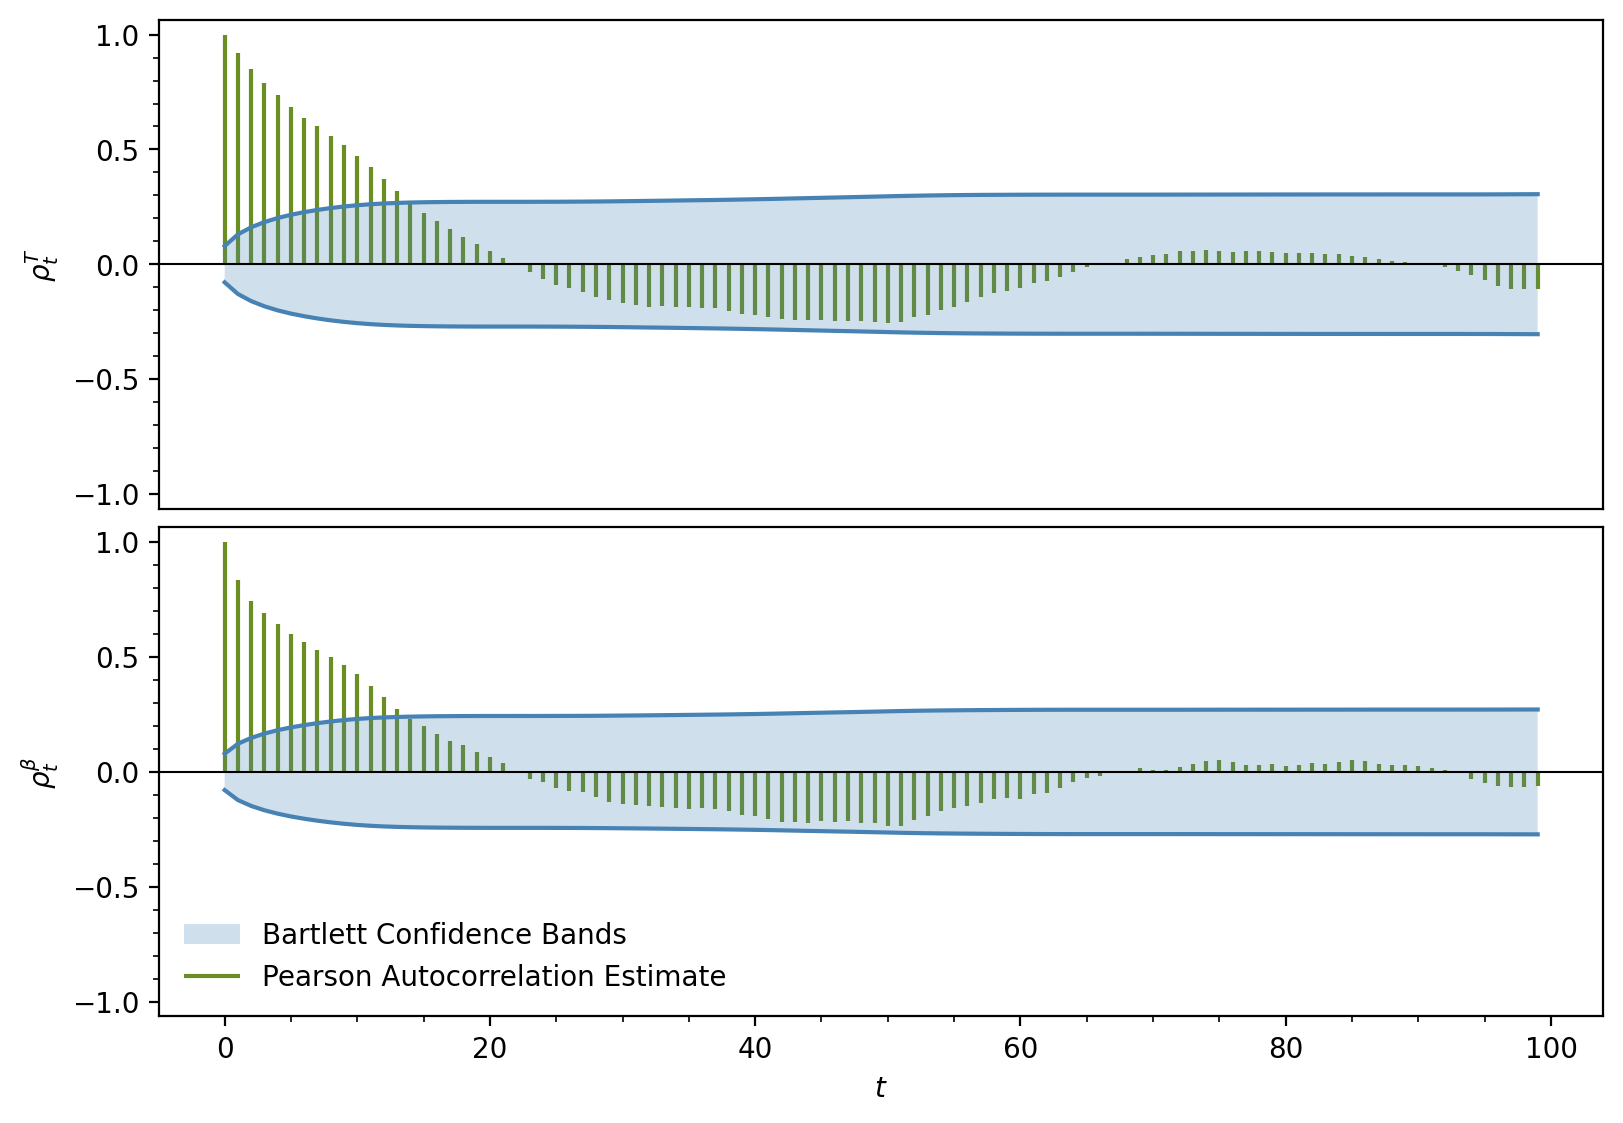

In [17]:
# Plot: Pearson Autocorrelation Coefficient

fig, ax = plt.subplots(2, 1, figsize=(8, 5.5))

ax[0].fill_between(ttt, -2.5 * TAerr, 2.5 * TAerr, color='steelblue', edgecolor='none', alpha=0.25)

ax[0].vlines(ttt, 0, TAcorr, zorder=-1)

ax[0].plot(ttt, -2.5 * TAerr, c='steelblue')
ax[0].plot(ttt, 2.5 * TAerr, c='steelblue')

ax[0].axhline(0, c='k', lw=0.75)

ax[0].set_ylim(-ax[0].set_ylim()[1], ax[0].set_ylim()[1])

ax[0].set_ylabel(r'$\rho_t^T$')

ax[0].get_xaxis().set_visible(False)

ax[1].fill_between(ttt, -2.5 * bAerr, 2.5 * bAerr, color='steelblue', edgecolor='none', alpha=0.25, label='Bartlett Confidence Bands')

ax[1].vlines(ttt, 0, bAcorr, zorder=-1, label='Pearson Autocorrelation Estimate')

ax[1].plot(ttt, -2.5 * bAerr, c='steelblue')
ax[1].plot(ttt, 2.5 * bAerr, c='steelblue')

ax[1].axhline(0, c='k', lw=0.75)

ax[1].set_ylim(-ax[1].set_ylim()[1], ax[1].set_ylim()[1])

ax[1].set_ylabel(r'$\rho_t^\beta$')

ax[1].legend(loc='lower left')

ax[1].set_xlabel(r'$t$')

plt.savefig('wrong/mcmc_acorr_good.jpg', dpi=300)
plt.show()
plt.close()

In [18]:
# Data: Sample Parameter Space

ll = 101000

samp1, ac1 = metroMCMC(ll, 13.0, 1.86, II, ff, uII, h = 0.005)
samp2, ac2 = metroMCMC(ll, 10.0, 1.98, II, ff, uII, h = 0.005)
samp3, ac3 = metroMCMC(ll, 15.5, 1.92, II, ff, uII, h = 0.005)

TSamp11 = 30.0 * samp1[:, 0]
bSamp11 = samp1[:, 1]

TSamp22 = 30.0 * samp2[:, 0]
bSamp22 = samp2[:, 1]

TSamp33 = 30.0 * samp3[:, 0]
bSamp33 = samp3[:, 1]

done:   generated 101000 samples after  313725 evaluations with acceptance ratio 32.19%
done:   generated 101000 samples after  313610 evaluations with acceptance ratio 32.21%
done:   generated 101000 samples after  338977 evaluations with acceptance ratio 29.80%


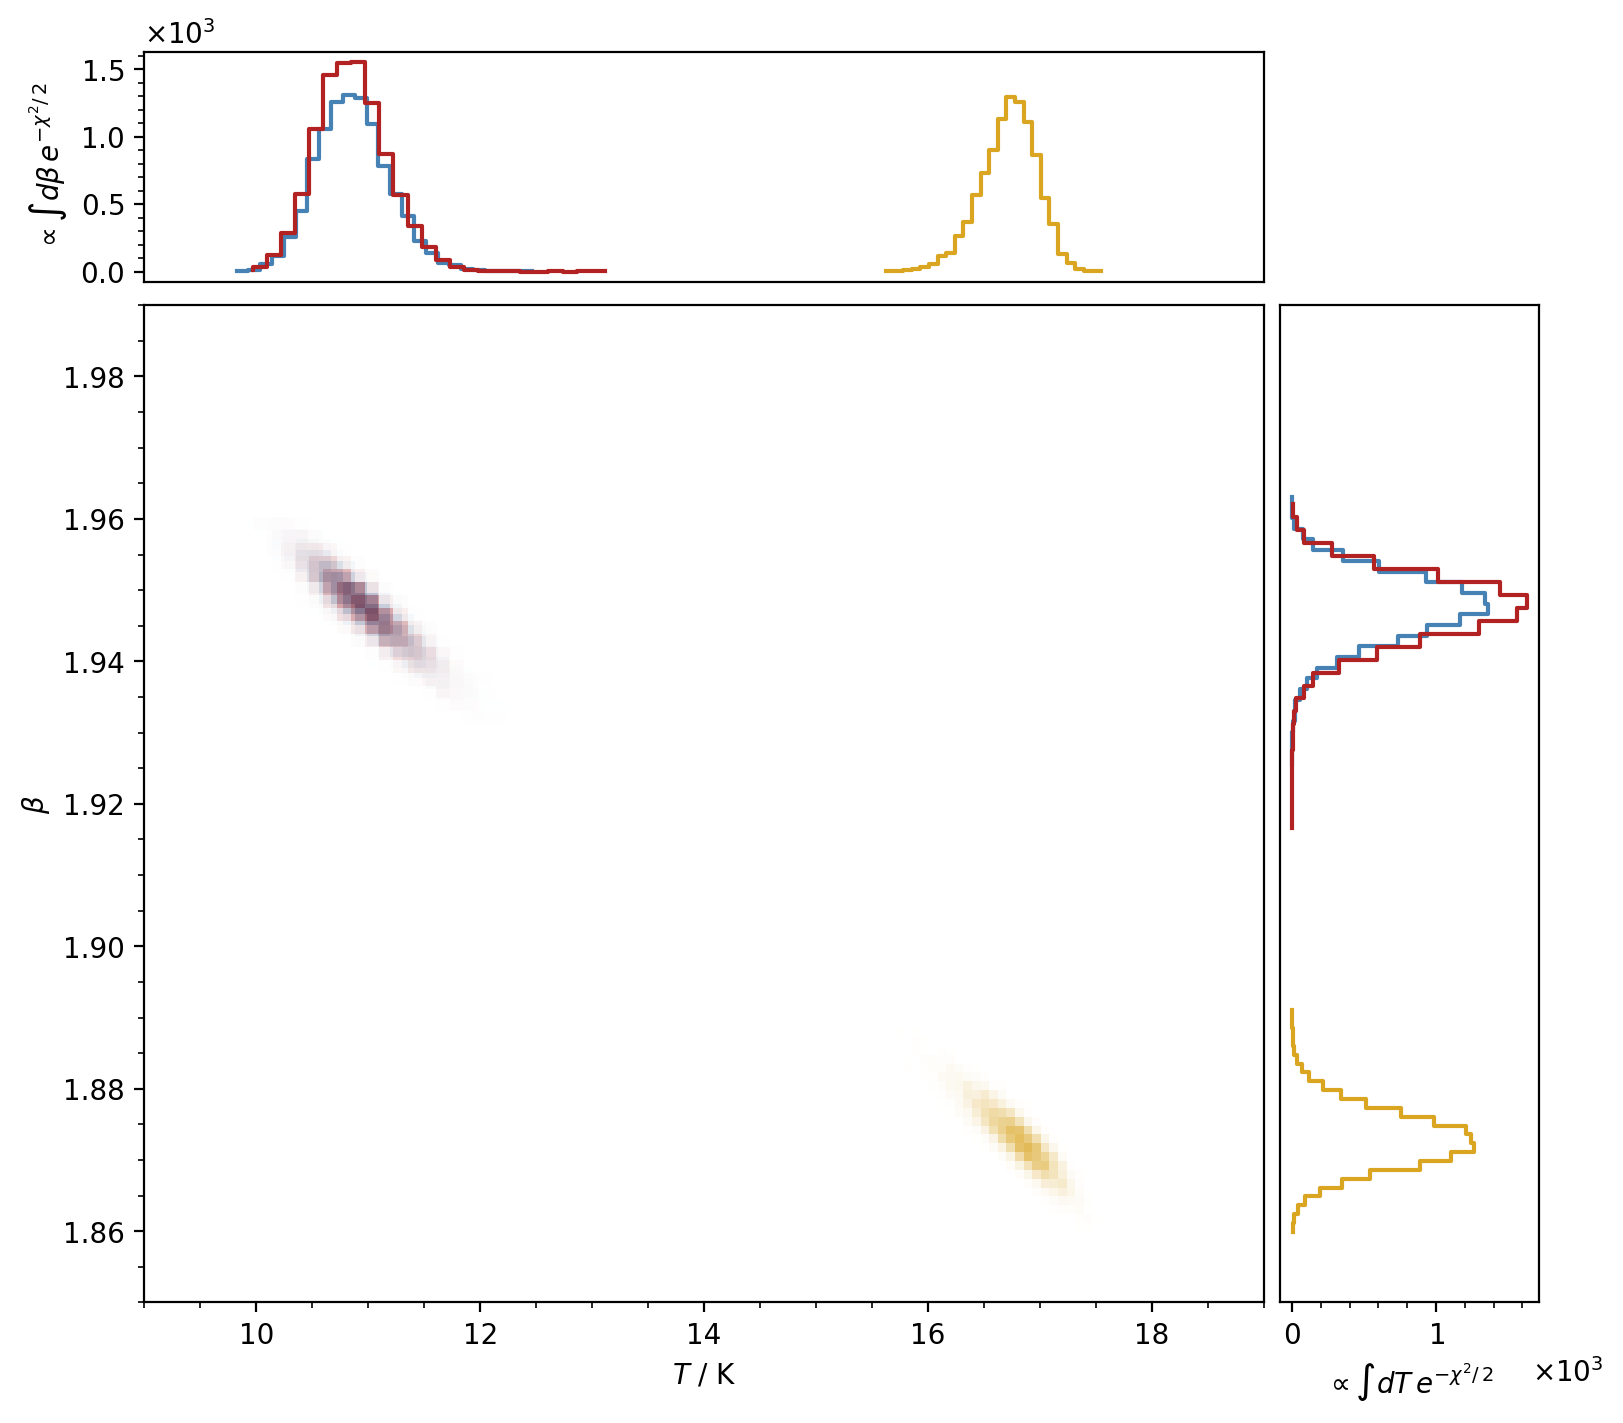

In [19]:
# Plot: Sampled Likelihood

TSamp111 = TSamp11[1000::10]
bSamp111 = bSamp11[1000::10]

TSamp222 = TSamp22[1000::10]
bSamp222 = bSamp22[1000::10]

TSamp333 = TSamp33[1000::10]
bSamp333 = bSamp33[1000::10]

bTHist1, TEdge1, bEdge1 = np.histogram2d(TSamp111, bSamp111, bins=25)

THist1, TBins1 = np.histogram(TSamp111, bins=25)
bHist1, bBins1 = np.histogram(bSamp111, bins=25)

THist1 = np.array([*THist1, THist1[-1]])
bHist1 = np.array([*bHist1, bHist1[-1]])

bTHist2, TEdge2, bEdge2 = np.histogram2d(TSamp222, bSamp222, bins=25)

THist2, TBins2 = np.histogram(TSamp222, bins=25)
bHist2, bBins2 = np.histogram(bSamp222, bins=25)

THist2 = np.array([*THist2, THist2[-1]])
bHist2 = np.array([*bHist2, bHist2[-1]])

bTHist3, TEdge3, bEdge3 = np.histogram2d(TSamp333, bSamp333, bins=25)

THist3, TBins3 = np.histogram(TSamp333, bins=25)
bHist3, bBins3 = np.histogram(bSamp333, bins=25)

THist3 = np.array([*THist3, THist3[-1]])
bHist3 = np.array([*bHist3, bHist3[-1]])

fig, ax = plt.subplots(2, 2, figsize=(8, 7), height_ratios=[1.5, 6.5], width_ratios=[6.5, 1.5])

hist1 = ax[1,0].pcolormesh(TEdge1, bEdge1, bTHist1.T, cmap=SteelBlue_r, alpha=1.0)
hist2 = ax[1,0].pcolormesh(TEdge2, bEdge2, bTHist2.T, cmap=FireBrick_r, alpha=0.5)
hist3 = ax[1,0].pcolormesh(TEdge3, bEdge3, bTHist3.T, cmap=GoldenRod_r, alpha=0.75)

ax[1,0].set_xlabel(r'$T$ / K')
ax[1,0].set_ylabel(r'$\beta$')

ax[1,0].set_xlim(xlim)
ax[1,0].set_ylim(ylim)

ax[0, 1].axis('off')

ax[0,0].step([], [])
ax[0,0].step(TBins1, THist1)
ax[0,0].step(TBins2, THist2)
ax[0,0].step(TBins3, THist3)
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylabel(r'$\propto \int d\beta \, e^{-\chi^2/\,2}$')
ax[0,0].get_xaxis().set_ticks([])
ax[0,0].yaxis.set_major_formatter(formatter)

ax[1,1].step([], [])
ax[1,1].step(bHist1, bBins1)
ax[1,1].step(bHist2, bBins2)
ax[1,1].step(bHist3, bBins3)
ax[1,1].set_ylim(ylim)
ax[1,1].set_xlabel(r'$\propto \int dT \, e^{-\chi^2/\,2}$')
ax[1,1].get_yaxis().set_ticks([])
ax[1,1].xaxis.set_major_formatter(formatter)

exp = ax[1,1].xaxis.get_offset_text()
cur = exp.get_position()
exp.set_position((cur[0] + 0.25, cur[1]))

plt.savefig('wrong/mcmc_lin_like.jpg', dpi=300)
plt.show()
plt.close()

In [20]:
# Data: Intensity Histogram

freq = np.logspace(11, 13, 300)

fff1 = np.array([])
III1 = np.array([])

fff2 = np.array([])
III2 = np.array([])

fff3 = np.array([])
III3 = np.array([])

for el in zip(TSamp111[::3] / 30.0, bSamp111[::3]):
    fff1 = np.append(fff1, freq)
    III1 = np.append(III1, modBB(freq, *el))

for el in zip(TSamp222[::3] / 30.0, bSamp222[::3]):
    fff2 = np.append(fff2, freq)
    III2 = np.append(III2, modBB(freq, *el))

for el in zip(TSamp333[::3] / 30.0, bSamp333[::3]):
    fff3 = np.append(fff3, freq)
    III3 = np.append(III3, modBB(freq, *el))

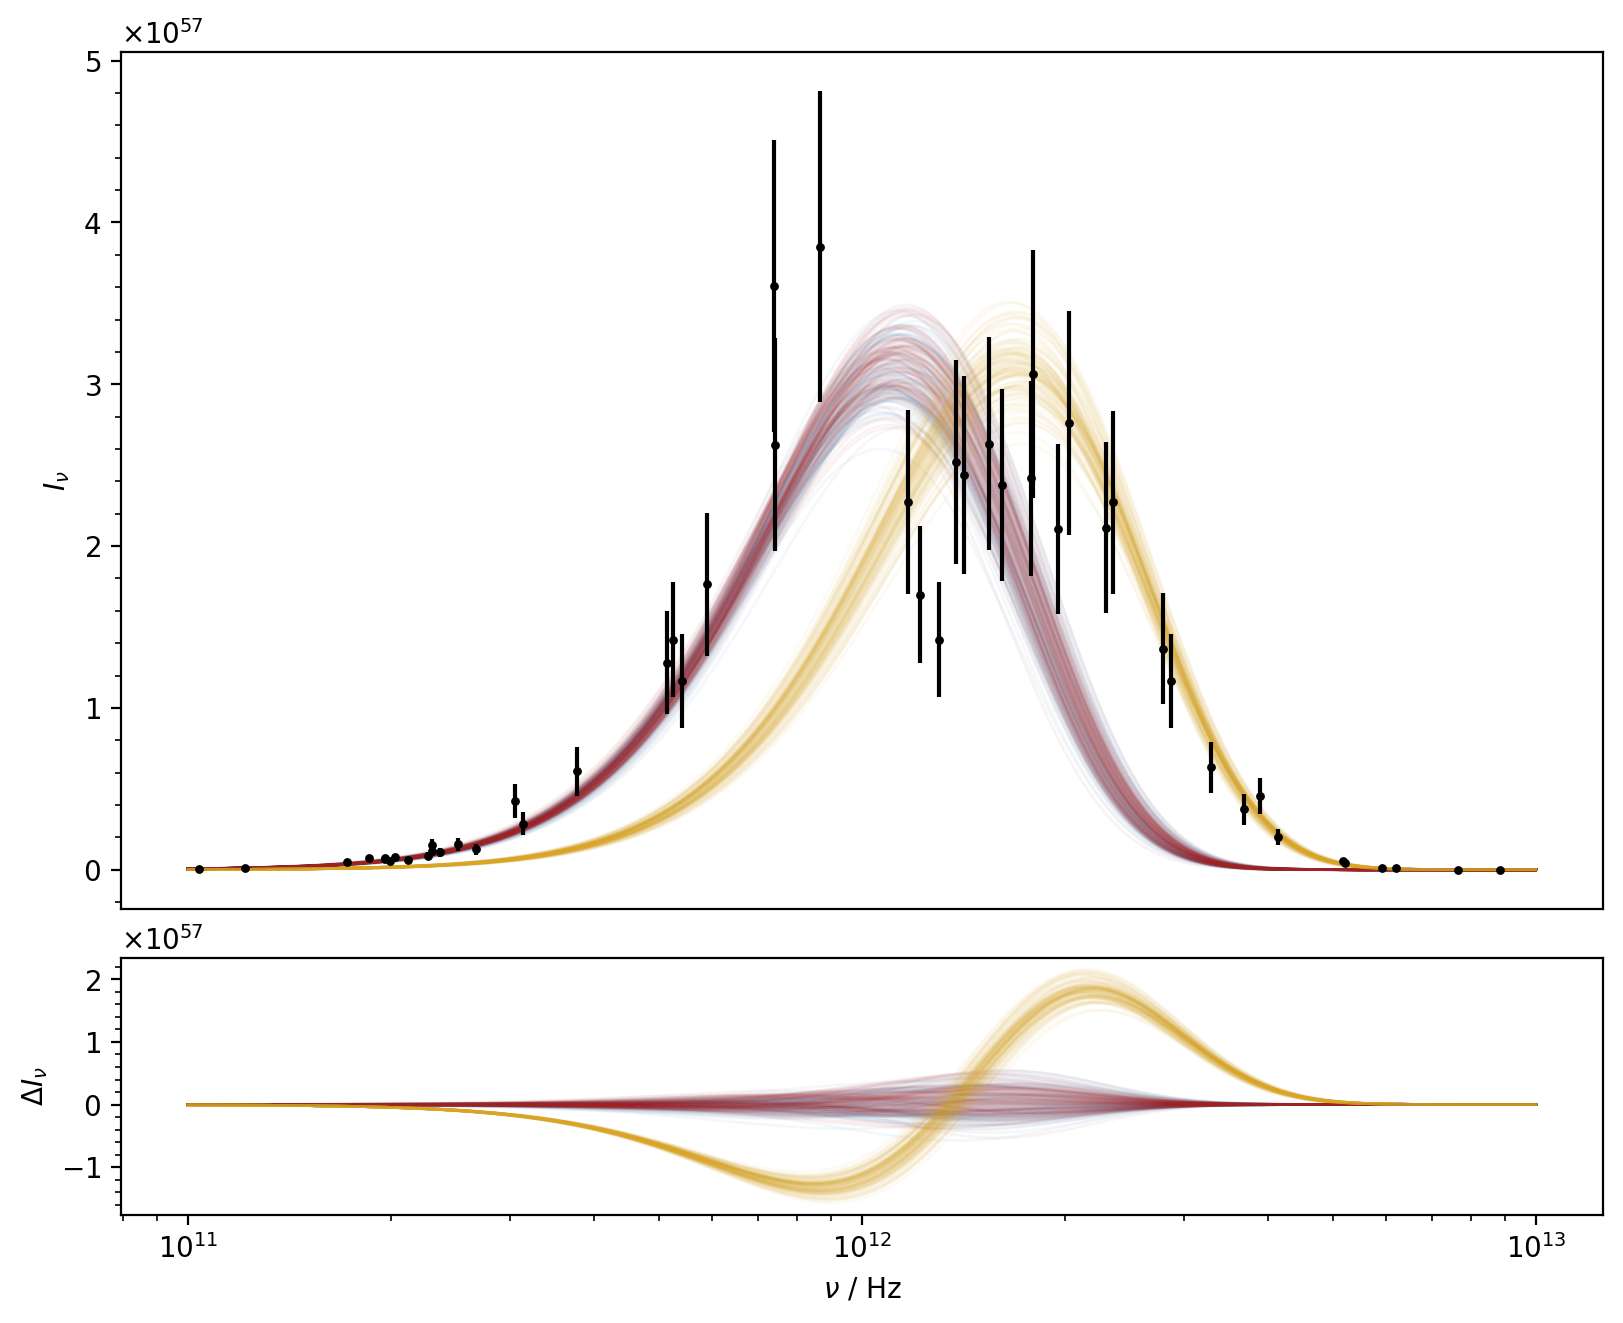

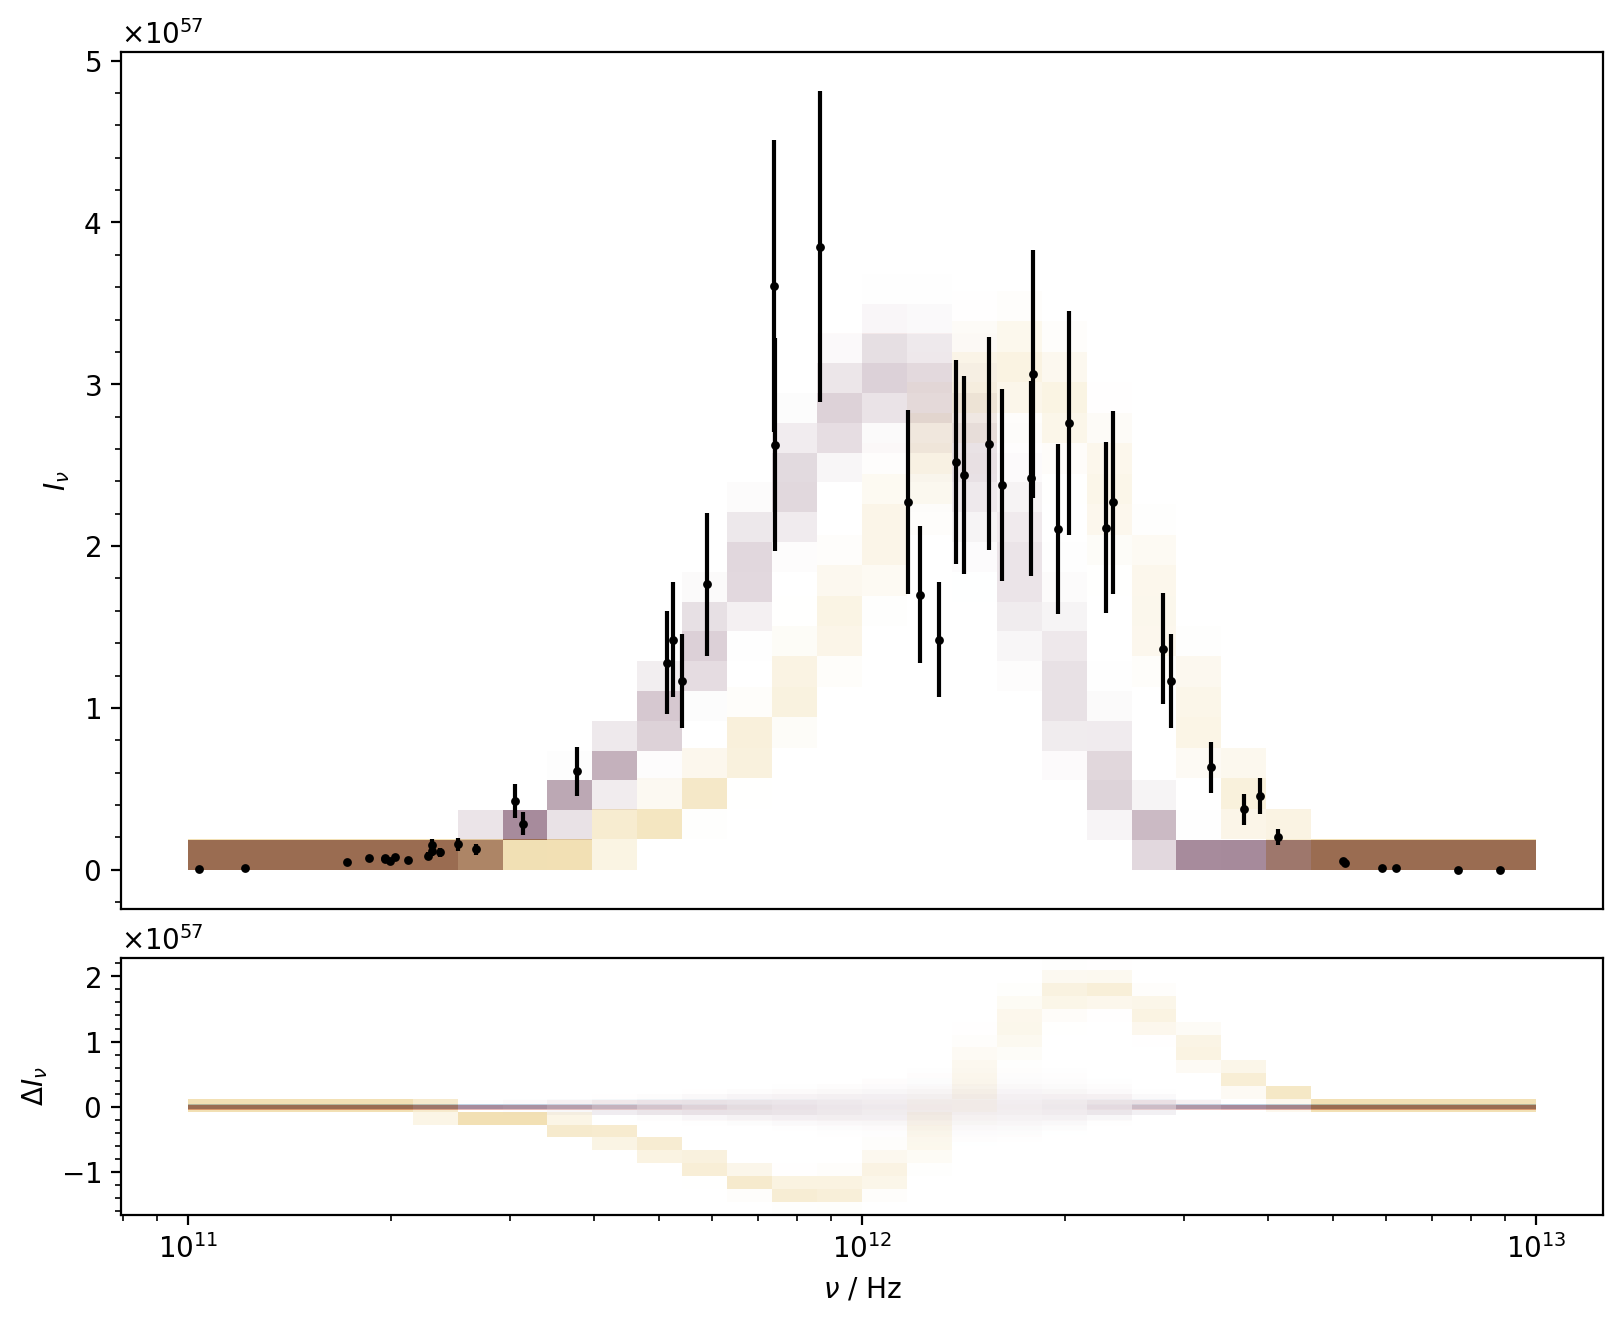

In [21]:
# Plot: Fit versus Samples

x = np.logspace(11, 13, 1000)

fig, ax = plt.subplots(2, 1, figsize=(8, 6.5), height_ratios=[5.0, 1.5])

samp1 = zip(TSamp111[::100] / 30.0, bSamp111[::100])
samp2 = zip(TSamp222[::100] / 30.0, bSamp222[::100])
samp3 = zip(TSamp333[::100] / 30.0, bSamp333[::100])

for el in samp1:
    ax[0].plot(x, modBB(x, *el), c='steelblue', lw=1, alpha=0.05, zorder=-1)
    ax[1].plot(x, modBB(x, *el) - modBB(x, *par), c='steelblue', lw=1, alpha=0.05, zorder=-3)

for el in samp2:
    ax[0].plot(x, modBB(x, *el), c='firebrick', lw=1, alpha=0.05, zorder=-1)
    ax[1].plot(x, modBB(x, *el) - modBB(x, *par), c='firebrick', lw=1, alpha=0.05, zorder=-2)

for el in samp3:
    ax[0].plot(x, modBB(x, *el), c='goldenrod', lw=1, alpha=0.05, zorder=-1)
    ax[1].plot(x, modBB(x, *el) - modBB(x, *par), c='goldenrod', lw=1, alpha=0.05, zorder=-1)

ax[0].errorbar(ff, II, yerr=uII, fmt='k.', ms=4.32)

ax[0].set_ylabel(r'$I_\nu$')

ax[0].set_xscale('log')
ax[0].get_xaxis().set_visible(False)

ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

limits = [ax[0].set_ylim(), ax[0].set_xlim()]

ax[1].set_ylabel(r'$\Delta I_\nu$')

ax[1].set_xscale('log')

ax[1].set_xlabel(r'$\nu$ / Hz')

ax[1].set_yticks([ -1e57, 0, 1e57, 2e57])

ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

plt.savefig('wrong/mcmc_comp_draws.jpg', dpi=300)
plt.show()
plt.close()

fig, ax = plt.subplots(2, 1, figsize=(8, 6.5), height_ratios=[5.0, 1.5])

IHist1, fEdge1, IEdge1 = np.histogram2d(fff1, III1, bins=[np.logspace(11, 13, 31), 20])
IHist2, fEdge2, IEdge2 = np.histogram2d(fff2, III2, bins=[np.logspace(11, 13, 31), 20])
IHist3, fEdge3, IEdge3 = np.histogram2d(fff3, III3, bins=[np.logspace(11, 13, 31), 20])

ax[0].pcolormesh(fEdge1, IEdge1, IHist1.T, cmap=SteelBlue_r, alpha=1.0)
ax[0].pcolormesh(fEdge2, IEdge2, IHist2.T, cmap=FireBrick_r, alpha=1/2)
ax[0].pcolormesh(fEdge3, IEdge3, IHist3.T, cmap=GoldenRod_r, alpha=1/3)

ax[0].errorbar(ff, II, yerr=uII, fmt='k.', ms=4.32)

ax[0].set_ylabel(r'$I_\nu$')

ax[0].set_xscale('log')
ax[0].get_xaxis().set_visible(False)

ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax[0].set_xlim(limits[1])
ax[0].set_ylim(limits[0])

IHist1, fEdge1, IEdge1 = np.histogram2d(fff1, III1 - modBB(fff1, *par), bins=[np.logspace(11, 13, 31), 20])
IHist2, fEdge2, IEdge2 = np.histogram2d(fff2, III2 - modBB(fff2, *par), bins=[np.logspace(11, 13, 31), 20])
IHist3, fEdge3, IEdge3 = np.histogram2d(fff3, III3 - modBB(fff3, *par), bins=[np.logspace(11, 13, 31), 20])

ax[1].pcolormesh(fEdge1, IEdge1, IHist1.T, cmap=SteelBlue_r, alpha=1.0)
ax[1].pcolormesh(fEdge2, IEdge2, IHist2.T, cmap=FireBrick_r, alpha=1/2)
ax[1].pcolormesh(fEdge3, IEdge3, IHist3.T, cmap=GoldenRod_r, alpha=1/3)

ax[1].set_ylabel(r'$\Delta I_\nu$')

ax[1].set_xscale('log')

ax[1].set_xlabel(r'$\nu$ / Hz')

ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax[1].set_xlim(limits[1])

plt.savefig('wrong/mcmc_comp_hist.jpg', dpi=300)
plt.show()
plt.close()